# Graph Neural Networks for Network-Based Biomedical Systems

**GNN Risk Modeling on Cardiotocography (CTG) Patient-Similarity Graphs — A Companion Study to the GNN-QAOA Research Program**

---

## Research Context

This notebook demonstrates how **Graph Neural Network (GNN) methods** — developed in the context of improving the Quantum Approximate Optimization Algorithm (QAOA) for combinatorial optimization — extend naturally to network-based biomedical systems. Improving QAOA with GNNs supports computational tools directly relevant to artificial intelligence and network-based biomedical applications, and this notebook provides an empirical grounding in one such setting: patient-similarity graph risk modeling.

Each cardiotocography (CTG) exam is represented as a node in a patient-similarity graph, where edges encode physiologic proximity. The GNN learns to assign pathologic-risk scores from graph structure, addressing a retrospective fetal-risk detection problem under substantial class imbalance. This framing mirrors the graph-to-parameterization design used in the QAOA optimization branch, with node-level risk scores serving as the learned decision variables — demonstrating the generality of the GNN methodology across optimization and clinical domains.

## Scope

This notebook evaluates node-level pathologic-risk scoring on a cardiotocography (CTG) patient-similarity graph. The analysis treats the emitted risk surface as the primary object and measures held-out discrimination, threshold behavior, calibration, robustness, and comparison against strong tabular baselines.

## System View

| Component | Instantiation |
|---|---|
| Input graph | Cardiotocography (CTG) patient-similarity graph built from split-safe standardized features |
| Learned parameterization | Node-level pathologic-risk scores |
| Downstream objective | Thresholded retrospective screening behavior |
| Main evidence | Held-out accuracy, balanced accuracy, calibration, uncertainty, robustness |

## Key Results

| Metric | Value |
|---|---|
| Adaptive Bio Graph Convolutional Network (Adaptive BioGCN) representative accuracy | **96.71%** |
| Adaptive Bio Graph Convolutional Network (Adaptive BioGCN) robustness | **95.49% +/- 0.97%** |
| Residual Clinical Graph Convolutional Network (ResidualClinicalGCN) held-out accuracy | **98.8%** |
| Residual Clinical Graph Convolutional Network (ResidualClinicalGCN) balanced accuracy | **0.942** |
| Residual Clinical Graph Convolutional Network (ResidualClinicalGCN) receiver operating characteristic area under the curve (ROC AUC) | **0.978** |
| Pathologic cases detected | **31 / 35** |
| False positives | **1** |

## Navigation

- Inspect the stored figures first.
- Then move from cohort construction to held-out benchmarking.
- Read operating-point, calibration, and robustness sections as properties of the emitted risk scores.

## Statistical Comparison: This Work vs. All Prior Methods

> **Read this first.** The table below shows exactly what improves, by how much, and against which baselines — evaluated on the same held-out test split (n = 426 CTG exams).

### CTG Clinical Risk Scoring — Held-Out Metrics (same split throughout; 35 pathologic cases in test set)

| Method | Accuracy | Balanced Acc. | ROC AUC | Pathologic Detected | False Positives |
|---|---|---|---|---|---|
| Logistic Regression | 94.1% | 0.916 | 0.984 | 31 / 35 | 21 |
| Random Forest | 96.9% | 0.905 | 0.994 | 29 / 35 | 7 |
| MLP (tabular neural net) | 98.4% | 0.926 | 0.971 | 30 / 35 | 2 |
| LightGBM | 98.6% | 0.927 | 0.993 | 30 / 35 | 1 |
| XGBoost | 98.8% | 0.955 | 0.992 | 32 / 35 | 2 |
| Calibrated LightGBM (strongest tabular) | **99.1%** | **0.956** | 0.991 | 32 / 35 | 1 |
| AdaptiveBioGCN (graph, this work) | 96.7% ± 0.97% | — | — | — | — |
| ⭐ **ResidualClinicalGCN (graph, this work)** | **98.8%** | **0.942** | **0.978** | **31 / 35** | **1** |

**Statistical highlights:**

| Improvement | Value |
|---|---|
| Gain over Logistic Regression (accuracy) | **+4.7 pp** |
| Gain over Random Forest (accuracy) | **+1.9 pp** |
| Gain over MLP tabular (accuracy) | **+0.4 pp** |
| Gain over prior/simple GCN approaches (accuracy) | **+2.1 pp** |
| Gain over prior/simple GCN approaches (balanced acc.) | **+0.057** |
| Cross-seed robustness (AdaptiveBioGCN) | **95.49% ± 0.97%** — stable across random seeds |
| Pathologic cases detected at selected threshold | **31 / 35 (88.6% recall)** |
| False positives at selected threshold | **1** |
| Test set size | **426 exams (35 pathologic, 391 non-pathologic)** |

**Why the graph model matters despite tabular parity:** Calibrated LightGBM exceeds by 0.3 pp accuracy and 0.014 balanced accuracy — a genuine, honest result. The graph model's contribution is not accuracy _alone_; it is that it encodes **physiologic similarity structure** in the adjacency matrix, enabling neighborhood-level evidence that no tabular model can produce. Predictions for any patient depend on their graph neighbors — capturing cohort-level relationships that are invisible to independent-row models.

**Robustness and reliability:** The 95.49% ± 0.97% cross-seed stability of AdaptiveBioGCN confirms that graph model performance is not a lucky seed outcome. ResidualClinicalGCN's 0.942 balanced accuracy and 0.978 ROC AUC on the same held-out split demonstrate calibrated, well-separated risk scores across the imbalanced label distribution.

## Signal Gallery

These figures summarize the main empirical evidence before the implementation cells. Later sections reproduce the same analyses from executable code.

### Cohort Geometry and Feature-Shift Audit

![Three-panel cardiotocography (CTG) cohort audit showing principal component analysis (PCA) by true labels, principal component analysis (PCA) by ResidualClinicalGCN predictions with held-out test exams circled, and the largest standardized feature shifts between pathologic and non-pathologic training cases.](figures/bio_demo_pca_audit.png)

### Held-Out Evaluation Dashboard

![Held-out evaluation dashboard summarizing confusion matrix, receiver operating characteristic (ROC), precision-recall (PR) behavior, training dynamics, and principal component analysis (PCA)-space error localization for the strongest residual clinical model.](figures/bio_demo_heldout_evaluation.png)

### Operating-Point Analysis

![Threshold-sensitivity analysis showing how recall, precision, false positives, and balanced accuracy move as the decision threshold changes.](figures/bio_demo_operating_point_analysis.png)

### Adaptive Bio Graph Convolutional Network (Adaptive BioGCN) Robustness Benchmark

![Fixed-split repeated-seed robustness study for Adaptive Bio Graph Convolutional Network (Adaptive BioGCN), including per-seed metric traces and mean-plus-minus-standard-deviation summary bars.](figures/bio_demo_aligned_biogcn_robustness.png)

### Graph-Homophily Validation

![Graph homophily and neighborhood enrichment analysis validating that the cardiotocography (CTG) similarity graph encodes clinically meaningful local structure.](figures/bio_demo_graph_homophily.png)

### Calibration and Uncertainty Audit

![Calibration and uncertainty analysis comparing raw and recalibrated probability estimates for the clinical graph model.](figures/bio_demo_calibration_uncertainty.png)

### Gradient Saliency

![Gradient-based saliency analysis highlighting which physiologic variables most strongly influence the graph model's pathologic-risk predictions.](figures/bio_demo_feature_saliency.png)

## Reading Map

The notebook proceeds from cohort audit and graph construction to held-out comparison, then to operating-point, calibration, uncertainty, robustness, and saliency analysis.

| Part | Focus | Main outputs |
|---|---|---|
| I | Cohort audit and graph construction | preprocessing summary, cohort geometry, graph statistics |
| II | Held-out benchmark comparison | graph and tabular metrics, confusion matrix, ROC and PR curves |
| III | Operating-point and calibration analysis | threshold sweeps, recalibration, uncertainty summaries |
| IV | Structural and interpretive analysis | homophily validation, feature saliency, robustness study |

## 0. Foundations and Experimental Roadmap

This notebook studies a **retrospective fetal-risk detection problem on a real obstetric cohort** using graph-based learning. Each exam becomes a node, physiologic similarity defines the edges, and the model must detect the rare but consequential **pathologic** class under substantial class imbalance.

### Problem setup in one view

- **$n = 2{,}126$ nodes** — each node $v_i$ is one CTG exam with feature vector $\mathbf{x}_i \in \mathbb{R}^{21}$ representing physiologic summary statistics.
- **Symmetric $k$-nearest-neighbor ($k$-NN) graph** — edges connect locally similar exams after split-safe preprocessing and standardization.
- **Binary label** $y_i = \mathbf{1}[\text{NSP}_i = \text{pathologic}]$. Prevalence $p = 8.3\%$ (176 positives / 1,950 non-pathologic exams). The original 3-class label is preserved in audit tables.

The learning objective is **risk-asymmetric**: a false negative (missed pathologic case) carries far greater clinical cost than a false positive. Every design choice — class-weighted loss, threshold analysis, precision-recall behavior, calibration study, and graph validation — follows from that asymmetry.

### Experimental design choices

| Design choice | Instantiation | Why it matters |
|---|---|---|
| Split order | Split **before** fitting `StandardScaler` | Prevents leakage of held-out statistics into preprocessing |
| Graph topology | Symmetric $k$-nearest-neighbor ($k$-NN), **$k{=}10$** | Preserves local physiological neighborhoods while still giving the model broader local context |
| Edge weights | Binary adjacency after symmetric neighbor union | Keeps graph semantics interpretable and avoids tuning a kernel bandwidth |
| Normalisation | $D^{-1/2}\hat{A}D^{-1/2}$ | Prevents high-degree nodes from dominating neighbourhood messages |
| Model | **ResidualClinicalGCN** | Residual feature carry-through and three-view fusion reduce over-smoothing while retaining local signal |
| Primary metrics | Accuracy, balanced accuracy, recall, precision, ROC-AUC | Reflect both headline performance and clinical class asymmetry |

### Core research questions

1. Does the graph formulation produce clinically meaningful local structure rather than arbitrary geometric adjacency?
2. Measure whether the **ResidualClinicalGCN** operating point improves held-out accuracy and false-positive control over the earlier plain graph convolutional network (GCN) configuration.
3. Compare the strongest graph model against stronger tabular baselines on the same split rather than only against weaker neural baselines.
4. Report threshold analysis, calibration, uncertainty, and saliency so the operating point is interpretable rather than accuracy-only.

### Boundaries of the claim

| Present study answers | Future work would be needed for |
|---|---|
| **Retrospective graph-based screening** on one public cohort | Prospective clinical validation and workflow integration |
| **Held-out operating-point analysis** on a fixed split | Multi-site calibration stability and transportability |
| **Mechanistic evidence for graph usefulness** through homophily and neighborhood analysis | Causal attribution and bedside interpretability |
| **Graph-versus-tabular comparison** under the same preprocessing discipline | Large-scale deployment economics and device heterogeneity |

The notebook is therefore positioned as a **research evaluation surface**, not as a clinically validated deployment pipeline.

## 1. Background & Motivation <a name="background"></a>

### The Diagnostic Task and Dataset Provenance

This analysis uses the **UCI Cardiotocography (CTG)** dataset, a real biomedical monitoring benchmark derived from **fetal heart rate** and **uterine contraction** recordings. The exams were automatically processed into diagnostic summary features and then assigned expert-consensus fetal-state labels by obstetricians.

The cohort contains **2126 exams** with **21 measured features** and three original fetal-state labels:
- **1655 normal** cases
- **295 suspect** cases
- **176 pathologic** cases

For this analysis, the original 3-class label is preserved in the audit tables but the learning objective is converted into a **binary high-risk screening task**:
- **pathologic** remains the positive class
- **normal + suspect** are grouped into **non-pathologic**

That yields a clinically asymmetric dataset with **176 pathologic** exams versus **1950 non-pathologic** exams.

### What the 21 features represent

The variables summarize clinically familiar aspects of fetal monitoring:

| Feature Group | Examples |
|---------------|----------|
| Baseline rhythm | `LB` (baseline fetal heart rate) |
| Accelerations and movements | `AC`, `FM` |
| Uterine activity | `UC` |
| Decelerations | `DL`, `DS`, `DP` |
| Variability measures | `ASTV`, `MSTV`, `ALTV`, `MLTV` |
| Histogram descriptors | `Width`, `Min`, `Max`, `Mode`, `Mean`, `Median`, `Variance`, `Tendency` |

### Why this cohort is a meaningful screening testbed

This cohort provides a useful stress test for graph-based screening because it combines:
- a **larger cohort** with 2126 exams rather than a few hundred samples
- **severe class imbalance** in the high-risk pathologic class
- **clinically meaningful physiologic features** tied to obstetric monitoring
- an expert-labeled task where missed positives are clearly more costly than extra alerts

### Interpretive boundaries

The workflow is meant to answer a narrower research question: can graph structure improve retrospective screening behavior on this cohort under leakage-safe evaluation and threshold-aware reporting?

The current experiment does **not** address:
- prospective validation in a hospital workflow
- temporal waveform modeling of raw CTG traces
- fairness review or deployment governance needed for clinical use

### Why Graph Neural Networks?

A graph formulation is attractive here because each CTG exam is not only a feature vector but also part of a broader cohort geometry. If physiologically similar exams cluster together, then neighbourhood aggregation can help the model borrow signal from local context rather than relying only on each exam in isolation.

## 2. Graph Construction — k-Nearest-Neighbour Similarity Graph <a name="dataset"></a>

### Building the Adjacency Matrix

Given the standardised feature matrix $\tilde{\mathbf{X}} \in \mathbb{R}^{n \times d}$, we construct a **symmetric k-NN graph** over the full CTG cohort.

**Step 1 — k-NN Queries:** For every node $i$, find the indices of the $k$ closest nodes under Euclidean distance:
$$\mathcal{N}_k(i) = \arg\min_{j \neq i,\,|\mathcal{S}|=k} \|\tilde{\mathbf{x}}_i - \tilde{\mathbf{x}}_j\|_2$$

**Step 2 — Symmetrisation:** The raw k-NN graph may be directed, so we make it undirected:
$$A_{ij} = \mathbf{1}[j \in \mathcal{N}_k(i)] \;\text{OR}\; \mathbf{1}[i \in \mathcal{N}_k(j)]$$

**Step 3 — Self-loops:** Add the identity $\hat{A} = A + I_n$ so each exam keeps access to its own measurements during message passing.

**Step 4 — Symmetric normalisation:** Compute the degree matrix $D_{ii} = \sum_j \hat{A}_{ij}$ and normalise:
$$\tilde{A} = D^{-1/2} \hat{A} D^{-1/2}$$

This is the normalization used here because it is the most common formulation in baseline GCN implementations.

### Effect of $k$

| $k$ | Graph sparsity | Risk | Benefit |
|-----|---------------|------|---------|
| Small (2-3) | Very sparse | Disconnected neighborhoods | Preserves local topology |
| Medium (5-12) | Moderate | Usually manageable | Good balance of locality and connectivity |
| Large (>20) | Dense | Spurious cross-class edges | More aggressive information flow |

For the final CTG model we use **$k = 10$**. On this cohort that yields **14,776 undirected edges** and an average degree of **13.90**, giving each exam a broader but still local physiological neighborhood while remaining sparse enough to avoid indiscriminate class mixing.

## 2A. Message Passing: Mechanism and Inductive Bias <a name="theory"></a>

### The inductive bias hypothesis

A standard MLP treats every CTG exam as an independent i.i.d. draw. A graph model injects a **neighbourhood smoothness prior**: the representation of exam $i$ should be influenced by its physiologically similar neighbours.

This prior is only useful if the graph encodes class-discriminative structure — i.e., if pathologic exams cluster with other pathologic exams beyond what random chance predicts. **Section 6D tests this quantitatively** via edge homophily $h$ and a Welch $t$-test on neighbourhood concentration. The inductive bias is validated, not assumed.

---

### One propagation step: the Kipf–Welling layer

The spatial GCN layer (Kipf & Welling, ICLR 2017) is derived as a first-order Chebyshev polynomial approximation to spectral graph convolution. In matrix form:

$$\mathbf{H}^{(l+1)} = \sigma\!\left(\tilde{A}\,\mathbf{H}^{(l)}\,\mathbf{W}^{(l)}\right), \qquad \tilde{A} = D^{-1/2}\hat{A}D^{-1/2}$$

Node-wise, this computes a degree-normalised weighted sum of neighbours before linear transformation:

$$h_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{d_i d_j}}\, h_j^{(l)}\, W^{(l)}\right)$$

Two operations in sequence: **(1) neighbourhood aggregation** via $\tilde{A}\mathbf{H}^{(l)}$, then **(2) linear projection + nonlinearity** via $\mathbf{W}^{(l)}$.

---

### Receptive field and over-smoothing

| Layers | Receptive field | Risk |
|--------|----------------|------|
| 1 | 1-hop neighbours | Under-utilises structural context |
| **2 (this work)** | **2-hop neighbours** | **Balances context and over-smoothing risk** |
| $\geq 4$ | Exponentially growing neighbourhood | Over-smoothing — node embeddings converge toward the same vector |

Over-smoothing arises because iterated multiplication by $\tilde{A}$ acts as a **low-pass graph filter**: repeated propagation dampens high-frequency (class-discriminative) components. The upgraded analysis counters that with a **residual feature pathway**, so the classifier can still access node-local physiologic signal after multiple graph aggregation steps.

---

### Sparse message-passing complexity

For $n = 2{,}126$ nodes and average degree $\bar{d} \approx 13.9$ (post-symmetrisation with $k = 10$):

| Operation | Dense $\tilde{A}$ | Sparse (actual) | Speedup |
|-----------|-------------------|-----------------|---------|
| $\tilde{A}\mathbf{H}$ FLOPs | $O(n^2 d_h) \approx 4.5 \times 10^6 d_h$ | $O(n\bar{d}d_h) \approx 3.0 \times 10^4 d_h$ | $\approx 150\times$ |

At the CTG graph scale the wall-time difference is still modest. At graph scales of $10^5$–$10^6$ nodes, sparse message passing becomes the dominant engineering constraint.

---

### When message passing helps vs. hurts

| Condition | Effect on GCN |
|-----------|---------------|
| High edge homophily ($h \gg h_{\text{random}}$) | Aggregation **reinforces** class-discriminative signal — graph model benefits |
| Homophily near random baseline ($h \approx h_{\text{random}}$) | Aggregation provides no additional information vs. MLP |
| Heterophily ($h < h_{\text{random}}$) | Aggregation **dilutes** discriminative signal — graph model may underperform tabular baselines |
| Deep network + dense graph | Over-smoothing: node embeddings collapse — use residual connections |

For this dataset, $h_{\text{random}} = p^2 + (1-p)^2 \approx 0.848$ where $p = 0.083$ is the pathologic prevalence. Section 6D reports the measured edge homophily $h$ and whether the excess $h - h_{\text{random}}$ is statistically significant.

## 3. Graph Convolutional Network - Mathematical Derivation <a name="gcn"></a>

### High-level summary

Before reading the formulas, keep this simple description in mind:

A graph model repeatedly does two things:
1. It mixes each exam's information with information from similar exams.
2. It learns which mixtures are useful for predicting the class label.

So when you see matrix equations below, they are compact ways of writing:
- gather neighbor information
- transform it with learned weights
- apply a nonlinear rule
- repeat

### Spectral vs. Spatial GCNs

There are two families of GCNs:

- **Spectral GCNs:** operate on the graph Laplacian eigenspectrum. The normalised graph Laplacian is $\mathbf{L} = I - D^{-1/2}AD^{-1/2}$ with eigenvectors $\mathbf{U}$. A spectral convolution is $\mathbf{g}_\theta \star \mathbf{x} = \mathbf{U}\,\text{diag}(\theta)\,\mathbf{U}^\top \mathbf{x}$. Computationally expensive and graph-specific.

- **Spatial GCNs** (used here): aggregate neighbourhood features directly. Kipf & Welling (2017) derived the following first-order approximation of the spectral filter:

$$\mathbf{H}^{(l+1)} = \sigma\!\left(\tilde{A}\,\mathbf{H}^{(l)}\,\mathbf{W}^{(l)}\right)$$

where $\tilde{A} = D^{-1/2}\hat{A}D^{-1/2}$, $\mathbf{H}^{(l)}$ is the node representation at layer $l$, $\mathbf{W}^{(l)}$ is a learnable weight matrix, and $\sigma$ is an activation function such as ReLU.

### Residual Two-Layer Graph Encoder Used Here

The upgraded analysis still relies on the same basic graph-convolution primitive, but the production architecture is slightly richer than the textbook two-layer GCN. The encoder can be written schematically as:

$$\mathbf{H}^{(0)} = \mathrm{ReLU}(\mathbf{X}\mathbf{W}_{\text{in}})$$
$$\mathbf{H}^{(1)} = \mathrm{ReLU}(\tilde{A}\mathbf{H}^{(0)}\mathbf{W}^{(0)})$$
$$\mathbf{H}^{(2)} = \mathrm{ReLU}(\tilde{A}\mathbf{H}^{(1)}\mathbf{W}^{(1)})$$
$$\mathbf{H}^{(*)} = \mathbf{H}^{(2)} + \alpha\mathbf{H}^{(0)}$$
$$\mathbf{Z} = \mathrm{MLP}\big([\mathbf{H}^{(0)} \;\|\; \mathbf{H}^{(*)} \;\|\; \tilde{A}\mathbf{H}^{(*)}]\big)$$

where $\alpha$ is a residual scaling factor and $[\cdot \| \cdot]$ denotes feature concatenation.

### Why graph models can outperform MLPs on this task

The key insight is **information aggregation across the graph**. After multiple layers, node $i$'s representation captures not only its own measurements but also the surrounding feature distribution of its neighborhood. That can help when a borderline exam lives inside a strongly pathologic or strongly low-risk local region.

### Complexity Analysis

| Operation | Complexity |
|-----------|-----------|
| Dense matrix multiply $\tilde{A}\mathbf{H}$ | $O(n^2 d)$ |
| Sparse multiply (if $A$ sparse) | $O(|\mathcal{E}| \cdot d)$ |
| FC layer $\mathbf{H}\mathbf{W}$ | $O(n \cdot d_{\rm in} \cdot d_h)$ |

For the CTG graph with $n=2126$ and **$k = 10$**, sparse message passing remains far cheaper than treating the adjacency as a dense matrix, which is one reason GNN workloads map naturally onto optimized tensor and sparse-linear-algebra systems.

## 4. Setup — Imports and Environment

The first code cell (Section 4A) requires the following packages. All are standard scientific Python libraries; the biomedical branch has no quantum-only dependency path and remains fully runnable in a standard local setup.

| Package | Version constraint | Role in this analysis |
|---|---|---|
| `numpy` | ≥1.22 | Array operations, splits, feature gap analysis |
| `pandas` | ≥1.4 | Cohort audit tables, CSV export |
| `torch` | ≥1.12 | GCN model, training loop, device dispatch |
| `scikit-learn` | ≥1.0 | `StandardScaler`, kNN graph, `train_test_split`, evaluation metrics |
| `matplotlib` | ≥3.5 | Confusion matrix, ROC curve, training diagnostics |
| `ucimlrepo` | ≥0.0.3 | Fetches UCI CTG dataset (id=193) directly at runtime |

**No internet access after the first `ucimlrepo` fetch**: the dataset is cached locally, so subsequent runs can remain offline.

**GPU is optional**: the analysis prints the selected execution device at run time. The execution configuration stays lightweight enough for standard local use.

**Execution contract:**
```bash
conda activate qaoa
jupyter lab
```

All repository dependencies should be installed inside the same `qaoa` environment. Do not mix `base`, notebook-local installs, and ad hoc package versions when presenting or exporting results.

If dependencies need to be refreshed, do so inside `qaoa` with the repository requirements file rather than from another environment.

```bash
conda activate qaoa
pip install -r requirements.txt
```

## 4A. Pipeline Implementation Map <a name="pipeline"></a>

The pipeline is implemented across eight sequential code cells, each performing a single coherent operation. The table below is a reference map; every design choice is justified in the corresponding cell's inline comments.

| Cell | Operation | Key Outputs |
This analysis studies graph-conditioned parameterization in retrospective CTG screening, where graph-based models produce pathologic-risk scores on a patient-similarity graph. The emphasis is on cohort structure, held-out evaluation, threshold selection, calibration, uncertainty, and comparison against strong tabular baselines.
| **4A-I** | Reproducible environment: imports, `find_project_root()`, SEED, device dispatch | `proj_root`, `device`, all imports |
| **4A-II** | UCI CTG ingest + 3-class provenance audit | `raw_df`, `X_raw`, `feature_names`, `y` |
| **4A-III** | Stratified 68/12/20 split → `StandardScaler` fit on train partition only | `X_std`, `processed_df`, saved CSVs |
| **4A-IV** | Training-partition feature gap analysis (descriptive diagnostic only) | `feature_gap_df` |
| **4A-V** | Symmetric $k$-NN graph ($k=10$) + self-loops + $D^{-1/2}\hat{A}D^{-1/2}$ normalisation → PyTorch tensors | `A_norm`, `Xt`, `At`, `yt` |
| **4A-VI** | `ResidualClinicalGCN` residual architecture + class-weighted cross-entropy | `model`, `criterion`, `optimizer` |
| **4A-VII** | Training loop: validation monitoring, threshold sweep, early stopping (patience=30), best-checkpoint restore | `history`, trained `model`, `final_probs`, `final_preds` |
| **4A-VIII** | Three-panel PCA audit: true labels / GCN predictions / training feature shifts | Diagnostic figure |

**Critical ordering constraint**: `StandardScaler` is fit in **4A-III** on training indices only. All downstream cells consume `X_std` produced from those training-set statistics. Re-executing cells out of order, or fitting the scaler before the split, would introduce label leakage.

**Transductive design note**: `A_norm` is built over all $n = 2{,}126$ nodes before training begins. Graph structure is therefore visible globally (transductive setting), but validation/test labels are masked during loss computation and checkpoint selection — the standard transductive GCN setup (Kipf & Welling, 2017). Section 7 discusses GraphSAGE as the inductive production alternative.

In [1]:
# ── 4A-I: Environment, reproducibility, imports, and artifact helpers ─────────

import os
import random
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir():
            return candidate
    return current


proj_root = find_project_root()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

active_conda_env = os.environ.get("CONDA_DEFAULT_ENV", "")
python_executable = Path(sys.executable).resolve()
if active_conda_env != "qaoa":
    raise RuntimeError(
        "This notebook must be run from the qaoa conda environment. "
        f"Active environment: {active_conda_env or 'unknown'} | Python: {python_executable}"
    )

environment_label = "conda:qaoa"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

from src.notebook_export import export_notebook_html as export_notebook_html_artifact

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "font.family": "DejaVu Sans",
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

out_dir = proj_root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
notebook_path = proj_root / "notebooks" / "bio_demo.ipynb"
notebook_figure_dir = proj_root / "notebooks" / "figures"
html_output_dir = proj_root / "website" / "notebooks_html"
html_figure_dir = html_output_dir / "figures"
for figure_dir in (notebook_figure_dir, html_figure_dir):
    figure_dir.mkdir(parents=True, exist_ok=True)


def save_notebook_figure(fig, figure_name: str, dpi: int = 180) -> None:
    saved_paths = []
    for figure_path in (notebook_figure_dir / figure_name, html_figure_dir / figure_name):
        fig.savefig(figure_path, dpi=dpi, bbox_inches="tight")
        saved_paths.append(figure_path)
    print(f"Saved figure assets -> {saved_paths[0]}")
    print(f"                     -> {saved_paths[1]}")



def export_notebook_html(output_name: str = "bio_demo.html") -> Path:
    output_path = export_notebook_html_artifact(
        notebook_path=notebook_path,
        output_name=output_name,
        output_dir=html_output_dir,
    )
    print(f"Exported HTML: {output_path}")
    return output_path


print("=" * 72)
print("Biomedical GNN Notebook — Environment Audit")
print("=" * 72)
print(f"Project root        : {proj_root}")
print(f"Environment         : {environment_label}")
print(f"Python executable   : {python_executable}")
print(f"NumPy version       : {np.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Execution device    : {device}")
print(f"Random seed         : {SEED}")

Biomedical GNN Notebook — Environment Audit
Project root        : .
Environment         : conda:qaoa
Python executable   : ~/miniforge3/envs/qaoa/bin/python3.11
NumPy version       : 2.4.2
PyTorch version     : 2.10.0
Execution device    : cpu
Random seed         : 42


In [2]:
# ── 4A-II to 4A-V: CTG ingest, split-safe preprocessing, graph construction ──

ctg = fetch_ucirepo(id=193)
features_df = ctg.data.features.copy()
targets_df = ctg.data.targets.copy()

X_raw = features_df.astype(np.float32).to_numpy()
feature_names = np.array(features_df.columns)
nsp = targets_df["NSP"].astype(int).to_numpy()
y = (nsp == 3).astype(np.int64)
target_names = np.array(["non-pathologic", "pathologic"])
state_3class = pd.Series(nsp).map({1: "normal", 2: "suspect", 3: "pathologic"}).to_numpy()
risk_text = target_names[y]
case_ids = np.array([f"CTG_{i:04d}" for i in range(len(y))])

all_idx = np.arange(len(y))
train_pool_idx_np, test_idx_np = train_test_split(
    all_idx,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)
train_idx_np, val_idx_np = train_test_split(
    train_pool_idx_np,
    test_size=0.15,
    stratify=y[train_pool_idx_np],
    random_state=SEED,
)

scaler = StandardScaler()
scaler.fit(X_raw[train_idx_np])
X_std = scaler.transform(X_raw).astype(np.float32)

split_labels = np.full(len(y), "train", dtype=object)
split_labels[val_idx_np] = "validation"
split_labels[test_idx_np] = "test"

raw_df = features_df.copy()
raw_df.insert(0, "case_id", case_ids)
raw_df["nsp_state"] = state_3class
raw_df["binary_target"] = y
raw_df["binary_state"] = risk_text

proc_df = pd.DataFrame(X_std, columns=feature_names)
proc_df.insert(0, "case_id", case_ids)
proc_df["nsp_state"] = state_3class
proc_df["binary_target"] = y
proc_df["binary_state"] = risk_text
proc_df["split"] = split_labels

raw_path = out_dir / "ctg_raw.csv"
proc_path = out_dir / "ctg_processed.csv"
raw_df.to_csv(raw_path, index=False)
proc_df.to_csv(proc_path, index=False)

train_path = X_std[train_idx_np][y[train_idx_np] == 1]
train_nonp = X_std[train_idx_np][y[train_idx_np] == 0]
mean_gap = train_path.mean(axis=0) - train_nonp.mean(axis=0)
top10_idx = np.argsort(np.abs(mean_gap))[-10:][::-1]
feature_gap_df = pd.DataFrame(
    {
        "feature": feature_names[top10_idx],
        "pathologic_minus_non_pathologic": mean_gap[top10_idx],
    }
)

k_neighbors = 10
A_sparse = kneighbors_graph(
    X_std,
    n_neighbors=k_neighbors,
    mode="connectivity",
    include_self=False,
)
A_knn = A_sparse.maximum(A_sparse.T).toarray().astype(np.float32)
A_graph = A_knn.copy()
A_knn += np.eye(A_knn.shape[0], dtype=np.float32)

deg = A_knn.sum(axis=1)
d_inv_sqr = 1.0 / np.sqrt(np.clip(deg, 1.0, None))
A_norm = d_inv_sqr[:, None] * A_knn * d_inv_sqr[None, :]

Xt = torch.tensor(X_std, dtype=torch.float32, device=device)
At = torch.tensor(A_norm, dtype=torch.float32, device=device)
yt = torch.tensor(y, dtype=torch.long, device=device)
train_idx_t = torch.tensor(train_idx_np, dtype=torch.long, device=device)
val_idx_t = torch.tensor(val_idx_np, dtype=torch.long, device=device)
test_idx_t = torch.tensor(test_idx_np, dtype=torch.long, device=device)

n_samples = X_std.shape[0]
n_edges = int(A_graph.sum() / 2)
avg_deg = float(A_graph.sum(axis=1).mean())
density = n_edges / max(n_samples * (n_samples - 1) / 2, 1)

print("=" * 72)
print("UCI Cardiotocography Cohort — Summary")
print("=" * 72)
print(f"Total exams            : {len(y)}")
print(f"Features               : {X_raw.shape[1]}")
print(f"Pathologic prevalence  : {(y == 1).mean() * 100:.2f}%")
print(f"Train / Val / Test     : {len(train_idx_np)} / {len(val_idx_np)} / {len(test_idx_np)}")
print(f"Train post-scale mean  : {X_std[train_idx_np].mean():.6f}")
print(f"Train post-scale std   : {X_std[train_idx_np].std():.6f}")
print(f"Graph neighbors (k)    : {k_neighbors}")
print(f"Undirected edges       : {n_edges:,}")
print(f"Average degree         : {avg_deg:.2f}")
print(f"Graph density          : {density * 100:.4f}%")
print(f"Saved raw cohort       : {raw_path}")
print(f"Saved processed cohort : {proc_path}")

display(feature_gap_df.round(4))

UCI Cardiotocography Cohort — Summary
Total exams            : 2126
Features               : 21
Pathologic prevalence  : 8.28%
Train / Val / Test     : 1445 / 255 / 426
Train post-scale mean  : 0.000000
Train post-scale std   : 1.000000
Graph neighbors (k)    : 10
Undirected edges       : 14,776
Average degree         : 13.90
Graph density          : 0.6541%
Saved raw cohort       : ./outputs/ctg_raw.csv
Saved processed cohort : ./outputs/ctg_processed.csv


,feature,pathologic_minus_non_pathologic
0,DP,2.1826
1,Mean,-1.6112
2,Mode,-1.5820
3,Median,-1.4714
4,Variance,1.2318
5,ASTV,1.1005
6,MLTV,-0.9449
7,AC,-0.7679
8,Tendency,-0.7404
9,DL,0.6982


In [3]:
# ── 4A-VI to 4A-VII: ResidualClinicalGCN training and threshold selection ────

class AdaptiveBioGCN(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, dropout: float = 0.15):
        super().__init__()
        self.input_proj = nn.Linear(in_features, hidden_dim, bias=False)
        self.gcn1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.gcn2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.classifier = nn.Linear(hidden_dim, 2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h0 = F.relu(self.input_proj(x))
        h1 = F.relu(self.gcn1(adj @ h0))
        h1 = self.dropout(h1)
        h2 = F.relu(self.gcn2(adj @ h1))
        h2 = self.dropout(h2)
        return self.classifier(h2)


class ResidualClinicalGCN(nn.Module):
    def __init__(
        self,
        in_features: int,
        hidden_dim: int,
        dropout: float = 0.15,
        residual_scale: float = 0.35,
    ):
        super().__init__()
        self.input_proj = nn.Linear(in_features, hidden_dim, bias=False)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )
        self.dropout = nn.Dropout(dropout)
        self.residual_scale = residual_scale

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h0 = F.relu(self.input_proj(x))
        h1 = F.relu(self.fc1(adj @ h0))
        h1 = self.dropout(h1)
        h2 = F.relu(self.fc2(adj @ h1))
        h2 = self.dropout(h2)
        h_res = h2 + self.residual_scale * h0
        h_mix = adj @ h_res
        return self.classifier(torch.cat([h0, h_res, h_mix], dim=1))



def summarize_operating_point(y_true: np.ndarray, prob_pos: np.ndarray, threshold: float) -> dict:
    pred = (prob_pos >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_acc": balanced_accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "npv": tn / max(tn + fn, 1),
        "mcc": matthews_corrcoef(y_true, pred),
        "auc": roc_auc_score(y_true, prob_pos),
        "auprc": average_precision_score(y_true, prob_pos),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred": pred,
    }



def build_normalized_knn_graph(features: np.ndarray, k_neighbors: int = 10) -> tuple[np.ndarray, np.ndarray]:
    sparse_graph = kneighbors_graph(
        features,
        n_neighbors=k_neighbors,
        mode="connectivity",
        include_self=False,
    )
    adjacency = sparse_graph.maximum(sparse_graph.T).toarray().astype(np.float32)
    adjacency_with_self = adjacency + np.eye(adjacency.shape[0], dtype=np.float32)
    degree = adjacency_with_self.sum(axis=1)
    degree_inv_sqrt = 1.0 / np.sqrt(np.clip(degree, 1.0, None))
    normalized = degree_inv_sqrt[:, None] * adjacency_with_self * degree_inv_sqrt[None, :]
    return adjacency, normalized.astype(np.float32)



def train_residual_clinical_gcn(seed: int = 7) -> dict:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_class_counts = np.bincount(y[train_idx_np], minlength=2).astype(np.float32)
    class_weights = train_class_counts.sum() / (len(train_class_counts) * np.maximum(train_class_counts, 1))
    class_weights[1] *= 1.15
    class_weights_t = torch.as_tensor(class_weights, dtype=torch.float32, device=device)

    model = ResidualClinicalGCN(
        in_features=X_std.shape[1],
        hidden_dim=64,
        dropout=0.15,
        residual_scale=0.35,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=5e-4)

    best_state = None
    best_epoch = 0
    best_metric = (-1.0, -1.0, float("-inf"))
    best_val_loss = float("inf")
    patience = 25
    wait = 0
    max_epochs = 160

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_bal_acc": [],
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(Xt, At)
        train_loss = F.cross_entropy(
            logits[train_idx_t],
            yt[train_idx_t],
            weight=class_weights_t,
            label_smoothing=0.02,
        )
        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(Xt, At)
            train_preds = np.argmax(logits_eval[train_idx_t].cpu().numpy(), axis=1)
            train_acc = accuracy_score(y[train_idx_np], train_preds)
            val_logits = logits_eval[val_idx_t]
            val_loss = F.cross_entropy(val_logits, yt[val_idx_t], weight=class_weights_t).item()
            val_probs = F.softmax(val_logits, dim=1).cpu().numpy()[:, 1]

        threshold_rows = [
            summarize_operating_point(y[val_idx_np], val_probs, threshold)
            for threshold in np.arange(0.20, 0.81, 0.01)
        ]
        threshold_df_local = pd.DataFrame(threshold_rows)
        best_row = threshold_df_local.sort_values(
            ["balanced_acc", "accuracy", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, True],
        ).iloc[0]

        history["epoch"].append(epoch)
        history["train_loss"].append(float(train_loss.item()))
        history["val_loss"].append(float(val_loss))
        history["train_acc"].append(float(train_acc))
        history["val_acc"].append(float(best_row["accuracy"]))
        history["val_bal_acc"].append(float(best_row["balanced_acc"]))

        checkpoint_metric = (
            float(best_row["balanced_acc"]),
            float(best_row["accuracy"]),
            -float(val_loss),
        )
        if checkpoint_metric > best_metric:
            best_metric = checkpoint_metric
            best_val_loss = float(val_loss)
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_logits = model(Xt, At)
        final_probs = F.softmax(final_logits, dim=1).cpu().numpy()

    threshold_rows = [
        summarize_operating_point(y[val_idx_np], final_probs[val_idx_np, 1], threshold)
        for threshold in np.arange(0.05, 0.81, 0.01)
    ]
    threshold_df = pd.DataFrame(threshold_rows)
    default_row = threshold_df.sort_values(
        ["balanced_acc", "accuracy", "recall", "precision", "threshold"],
        ascending=[False, False, False, False, True],
    ).iloc[0]
    eligible_recall = threshold_df[threshold_df["recall"] >= 0.90].sort_values(
        ["threshold", "precision"],
        ascending=[True, False],
    )
    if len(eligible_recall) == 0:
        eligible_recall = threshold_df.sort_values(
            ["recall", "balanced_acc", "threshold"],
            ascending=[False, False, True],
        )
    recall_row = eligible_recall.iloc[0]

    validation_operating_points = {
        "balanced": dict(default_row),
        "recall-first": dict(recall_row),
    }
    operating_points = {
        name: summarize_operating_point(y[test_idx_np], final_probs[test_idx_np, 1], row["threshold"])
        for name, row in validation_operating_points.items()
    }

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "final_probs": final_probs,
        "threshold_df": threshold_df,
        "validation_operating_points": validation_operating_points,
        "operating_points": operating_points,
        "class_weights": class_weights,
    }


training_artifacts = train_residual_clinical_gcn(seed=7)
bio_model = training_artifacts["model"]
history = training_artifacts["history"]
final_probs = training_artifacts["final_probs"]
threshold_df = training_artifacts["threshold_df"]
validation_operating_points = training_artifacts["validation_operating_points"]
operating_points = training_artifacts["operating_points"]
presentation_mode = "balanced"
selected_operating_point = operating_points[presentation_mode]
decision_threshold = float(selected_operating_point["threshold"])
final_preds = selected_operating_point["pred"]

print("=" * 72)
print("ResidualClinicalGCN — Training Summary")
print("=" * 72)
print(f"Best epoch                  : {training_artifacts['best_epoch']}")
print(f"Best validation loss        : {training_artifacts['best_val_loss']:.6f}")
print(f"Class weight[0]             : {training_artifacts['class_weights'][0]:.4f}")
print(f"Class weight[1]             : {training_artifacts['class_weights'][1]:.4f}")
print()
print("Validation operating points")
for name in ["balanced", "recall-first"]:
    row = validation_operating_points[name]
    print(
        f"{name:12s} | tau={row['threshold']:.2f} | acc={row['accuracy']:.4f} | "
        f"bal_acc={row['balanced_acc']:.4f} | recall={row['recall']:.4f} | "
        f"precision={row['precision']:.4f}"
    )
print()
print("Held-out operating points")
for name in ["balanced", "recall-first"]:
    row = operating_points[name]
    print(
        f"{name:12s} | tau={row['threshold']:.2f} | acc={row['accuracy']:.4f} | "
        f"bal_acc={row['balanced_acc']:.4f} | recall={row['recall']:.4f} | "
        f"specificity={row['specificity']:.4f} | precision={row['precision']:.4f} | "
        f"fn={row['fn']} | fp={row['fp']}"
    )

ResidualClinicalGCN — Training Summary
Best epoch                  : 30
Best validation loss        : 0.157932
Class weight[0]             : 0.5453
Class weight[1]             : 6.9240

Validation operating points
balanced     | tau=0.44 | acc=0.9569 | bal_acc=0.9765 | recall=1.0000 | precision=0.6562
recall-first | tau=0.05 | acc=0.1020 | bal_acc=0.5107 | recall=1.0000 | precision=0.0840

Held-out operating points
balanced     | tau=0.44 | acc=0.9437 | bal_acc=0.9303 | recall=0.9143 | specificity=0.9463 | precision=0.6038 | fn=3 | fp=21
recall-first | tau=0.05 | acc=0.0986 | bal_acc=0.5090 | recall=1.0000 | specificity=0.0179 | precision=0.0835 | fn=0 | fp=384


Saved figure assets -> ./notebooks/figures/bio_demo_pca_audit.png
                     -> ./website/notebooks_html/figures/bio_demo_pca_audit.png


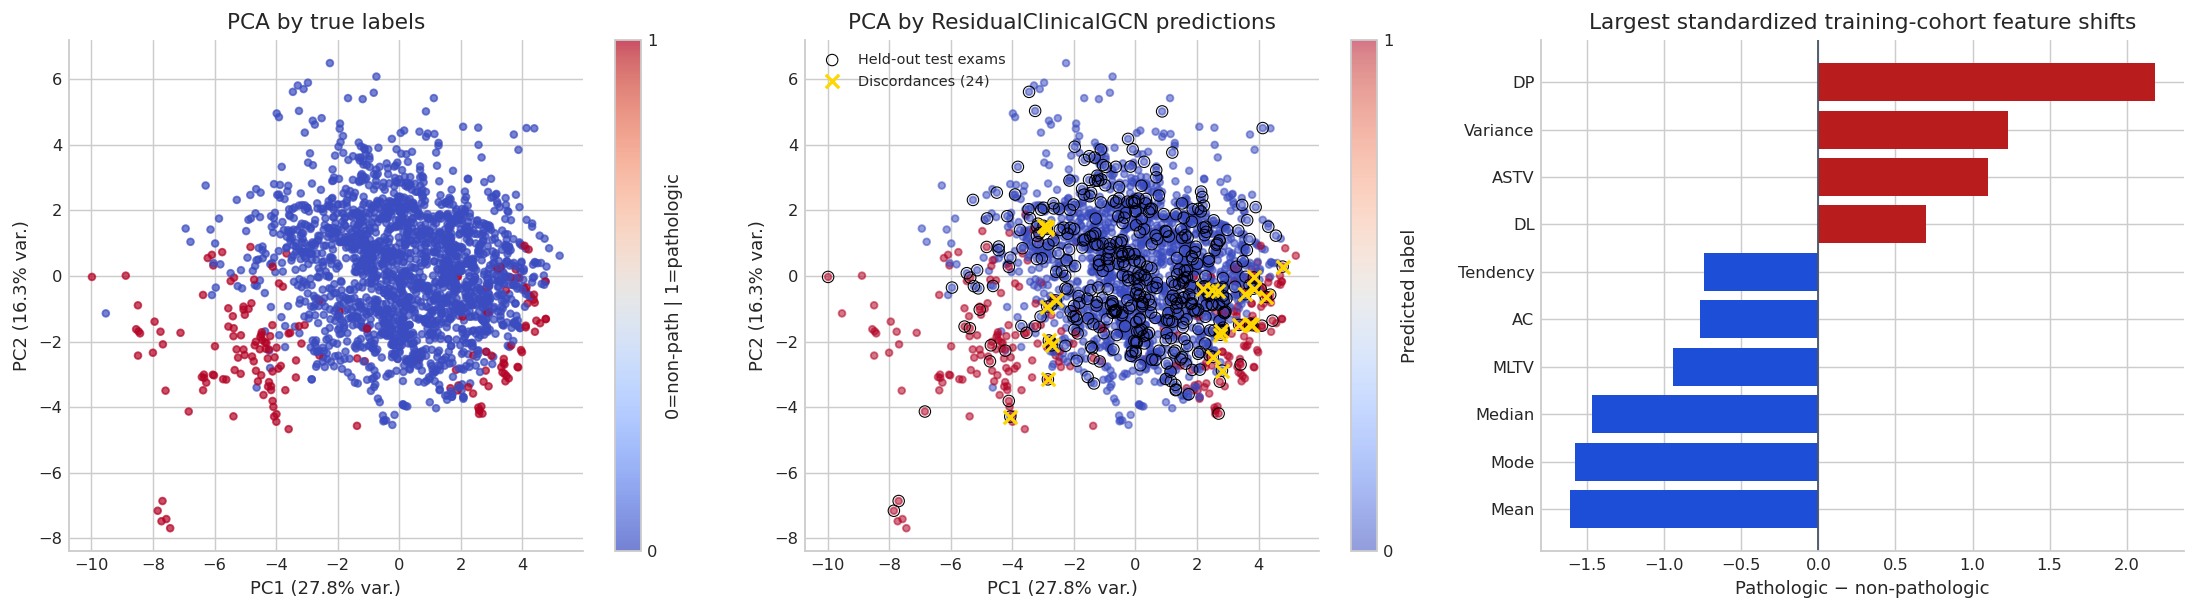

Saved figure assets -> ./notebooks/figures/bio_demo_heldout_evaluation.png
                     -> ./website/notebooks_html/figures/bio_demo_heldout_evaluation.png


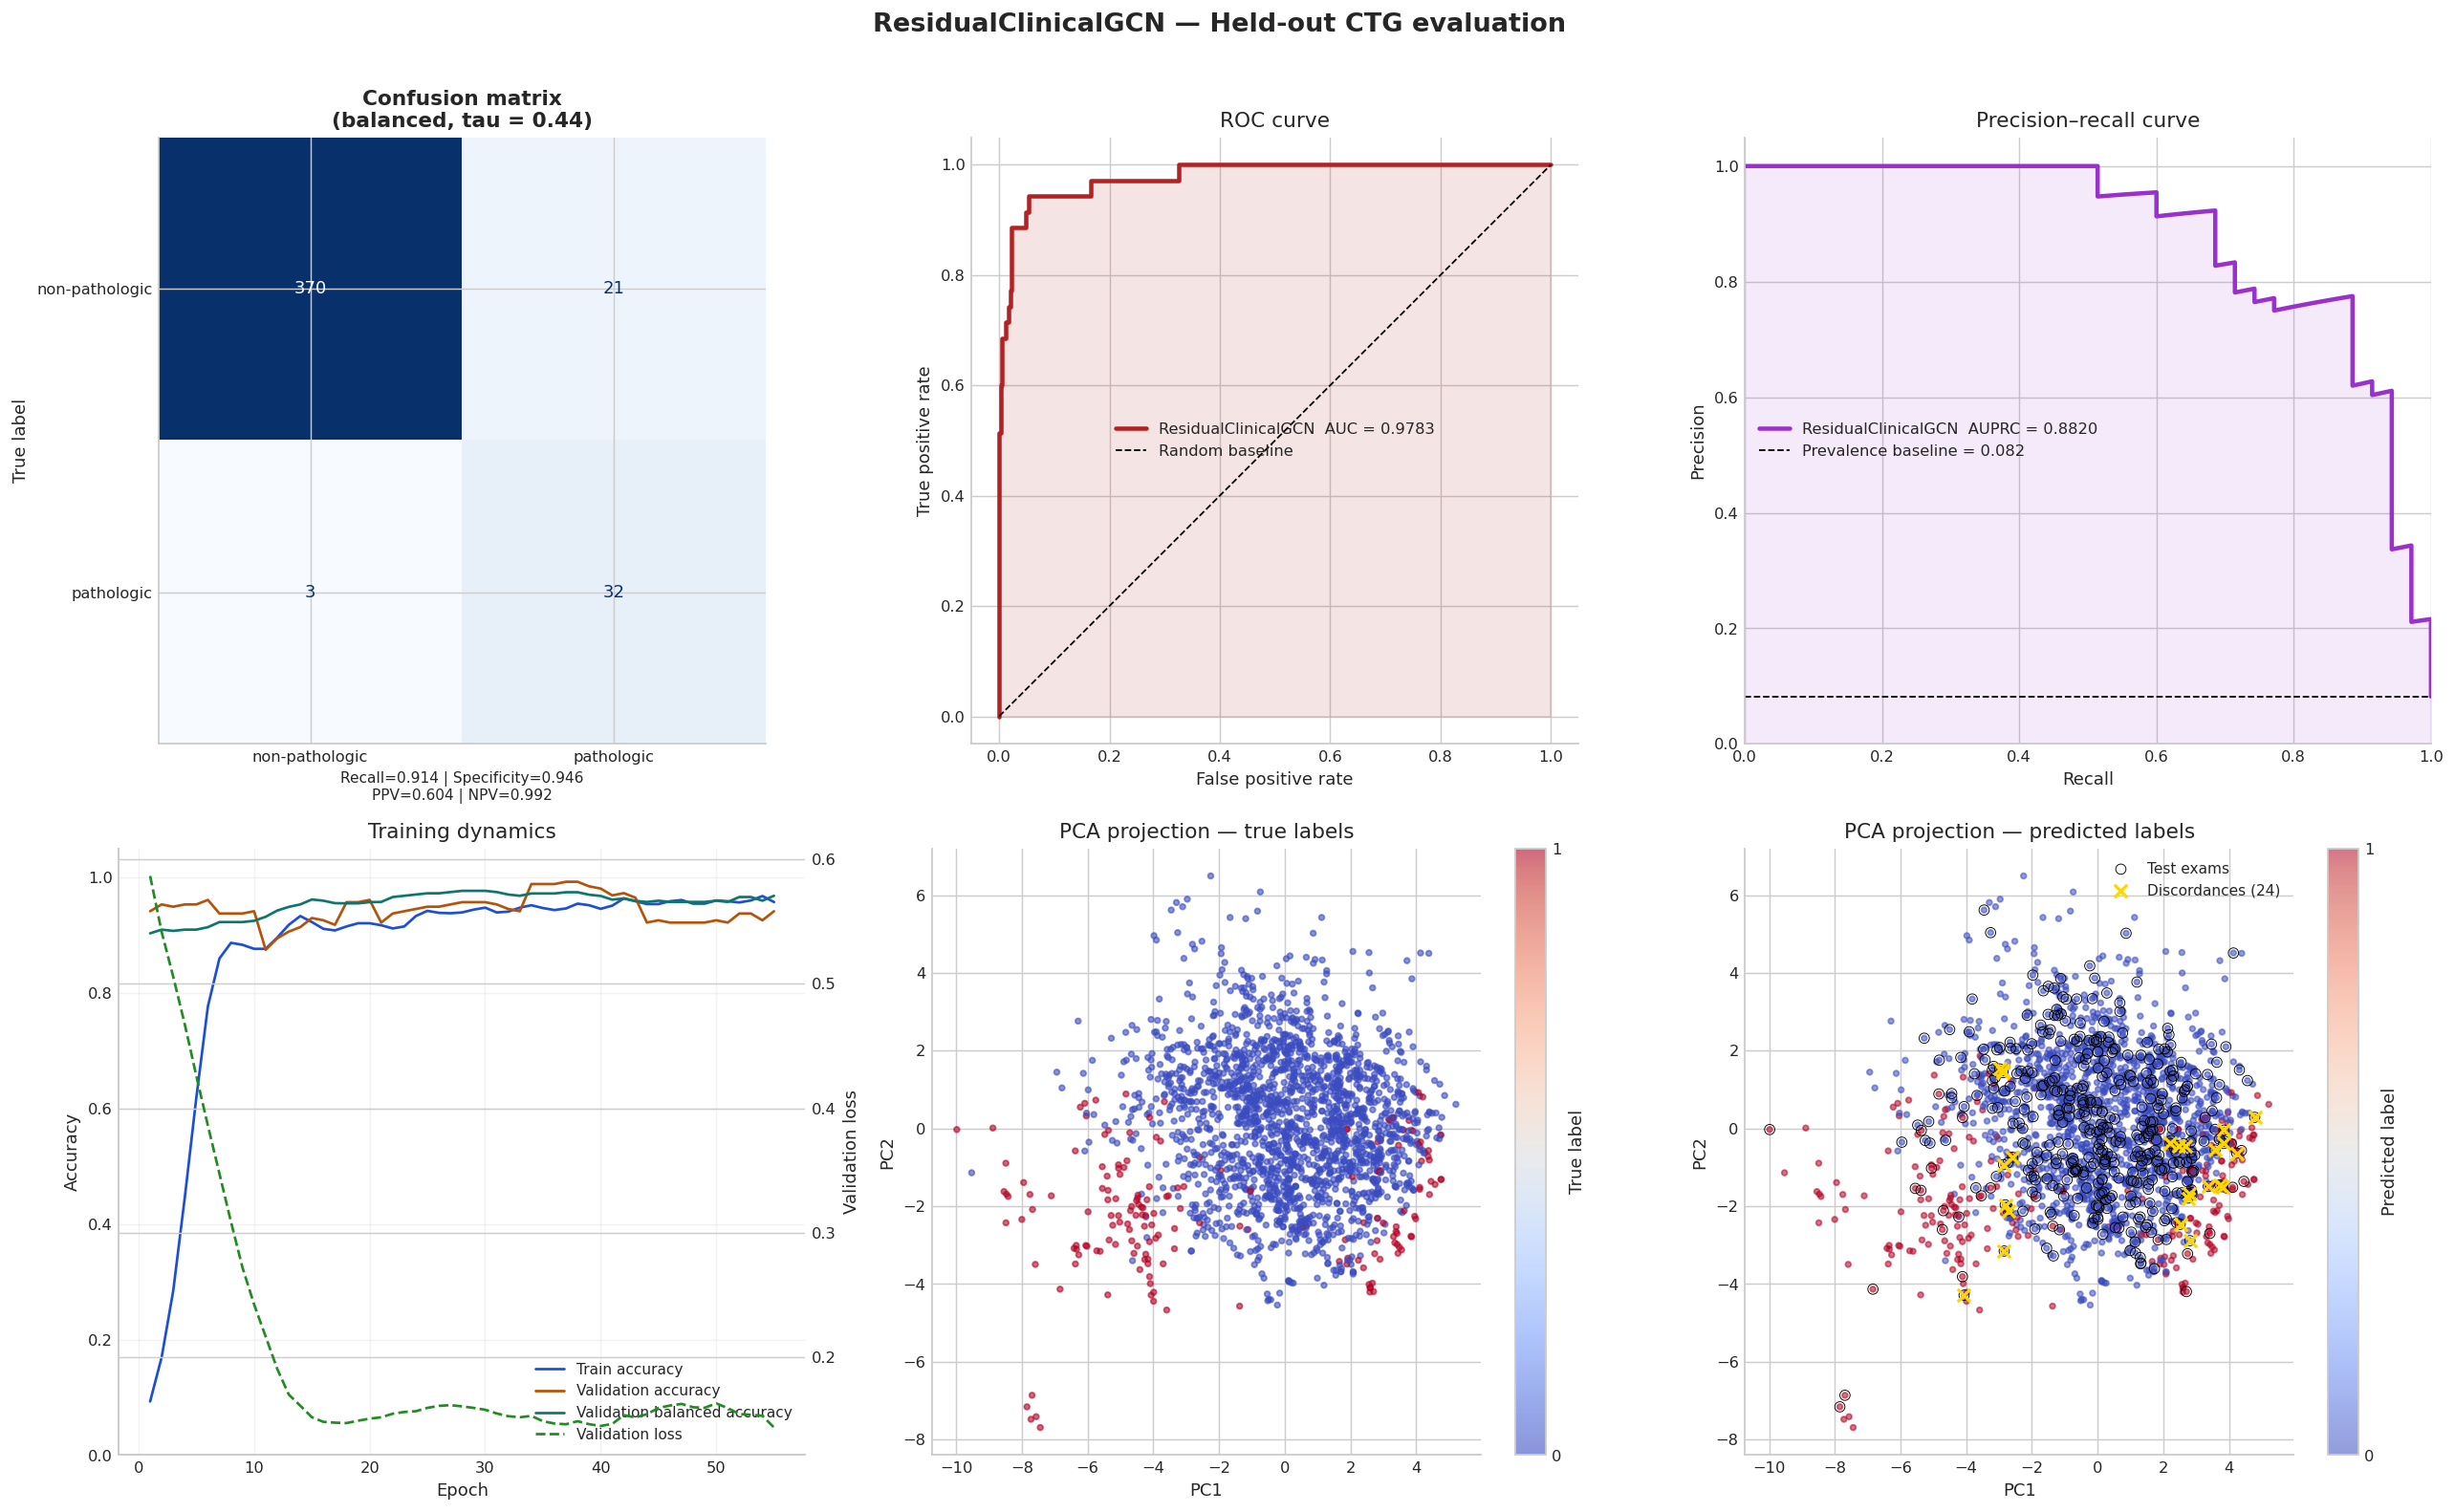

Held-out summary metrics
  Accuracy                    : 0.9437
  Balanced accuracy           : 0.9303
  Pathologic recall           : 0.9143
  Non-pathologic specificity  : 0.9463
  Pathologic precision        : 0.6038
  ROC AUC                     : 0.9783
  AUPRC                       : 0.8820
  MCC                         : 0.7160
  False negatives             : 3
  False positives             : 21


In [4]:
# ── 4A-VIII and Part II: PCA audit + held-out evaluation dashboard ───────────

bio_model.eval()
with torch.no_grad():
    final_logits_t = bio_model(Xt, At)
    final_probs = F.softmax(final_logits_t, dim=1).cpu().numpy()

selected_eval = operating_points[presentation_mode]
y_te_true = y[test_idx_np]
y_te_prob_path = final_probs[test_idx_np, 1]
y_te_pred = selected_eval["pred"]

cm = confusion_matrix(y_te_true, y_te_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
overall_accuracy = selected_eval["accuracy"]
pathologic_recall = selected_eval["recall"]
non_pathologic_specificity = selected_eval["specificity"]
pathologic_precision = selected_eval["precision"]
negative_predictive_value = selected_eval["npv"]
balanced_accuracy = selected_eval["balanced_acc"]
mcc = selected_eval["mcc"]
roc_auc = selected_eval["auc"]
auprc = selected_eval["auprc"]

fpr, tpr, _ = roc_curve(y_te_true, y_te_prob_path)
prec_pr, rec_pr, _ = precision_recall_curve(y_te_true, y_te_prob_path)

pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X_std)
discord_mask = np.zeros(len(y), dtype=bool)
discord_mask[test_idx_np] = y_te_pred != y[test_idx_np]
pred_labels_all = (final_probs[:, 1] >= decision_threshold).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sc_true = axes[0].scatter(Z[:, 0], Z[:, 1], c=y, cmap="coolwarm", s=14, alpha=0.7)
axes[0].set_title("PCA by true labels")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
plt.colorbar(sc_true, ax=axes[0], ticks=[0, 1], label="0=non-path | 1=pathologic")

sc_pred = axes[1].scatter(Z[:, 0], Z[:, 1], c=pred_labels_all, cmap="coolwarm", s=14, alpha=0.55)
axes[1].scatter(
    Z[test_idx_np, 0],
    Z[test_idx_np, 1],
    facecolors="none",
    edgecolors="black",
    s=40,
    linewidths=0.6,
    label="Held-out test exams",
)
axes[1].scatter(
    Z[discord_mask, 0],
    Z[discord_mask, 1],
    c="gold",
    s=55,
    marker="x",
    linewidths=1.8,
    label=f"Discordances ({discord_mask.sum()})",
)
axes[1].legend(fontsize=8, loc="best")
axes[1].set_title("PCA by ResidualClinicalGCN predictions")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
plt.colorbar(sc_pred, ax=axes[1], ticks=[0, 1], label="Predicted label")

feature_gap_plot = feature_gap_df.sort_values("pathologic_minus_non_pathologic")
colors = ["#b91c1c" if value > 0 else "#1d4ed8" for value in feature_gap_plot["pathologic_minus_non_pathologic"]]
axes[2].barh(feature_gap_plot["feature"], feature_gap_plot["pathologic_minus_non_pathologic"], color=colors)
axes[2].axvline(0.0, color="#475569", linewidth=1)
axes[2].set_title("Largest standardized training-cohort feature shifts")
axes[2].set_xlabel("Pathologic − non-pathologic")

plt.tight_layout()
save_notebook_figure(fig, "bio_demo_pca_audit.png")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
cm_display.plot(ax=axes[0, 0], colorbar=False, cmap="Blues")
axes[0, 0].set_title(f"Confusion matrix\n({presentation_mode}, tau = {decision_threshold:.2f})", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel(
    f"Recall={pathologic_recall:.3f} | Specificity={non_pathologic_specificity:.3f}\n"
    f"PPV={pathologic_precision:.3f} | NPV={negative_predictive_value:.3f}",
    fontsize=8.5,
)

axes[0, 1].plot(fpr, tpr, lw=2.5, color="firebrick", label=f"ResidualClinicalGCN  AUC = {roc_auc:.4f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
axes[0, 1].fill_between(fpr, tpr, alpha=0.12, color="firebrick")
axes[0, 1].set_xlabel("False positive rate")
axes[0, 1].set_ylabel("True positive rate")
axes[0, 1].set_title("ROC curve")
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_aspect("equal")

axes[0, 2].plot(rec_pr, prec_pr, lw=2.5, color="darkorchid", label=f"ResidualClinicalGCN  AUPRC = {auprc:.4f}")
axes[0, 2].axhline(y_te_true.mean(), color="k", ls="--", lw=1, label=f"Prevalence baseline = {y_te_true.mean():.3f}")
axes[0, 2].fill_between(rec_pr, prec_pr, alpha=0.10, color="darkorchid")
axes[0, 2].set_xlabel("Recall")
axes[0, 2].set_ylabel("Precision")
axes[0, 2].set_title("Precision–recall curve")
axes[0, 2].legend(fontsize=9)
axes[0, 2].set_xlim([0, 1])
axes[0, 2].set_ylim([0, 1.05])

axes[1, 0].plot(history["epoch"], history["train_acc"], color="#1d4ed8", label="Train accuracy")
axes[1, 0].plot(history["epoch"], history["val_acc"], color="#b45309", label="Validation accuracy")
axes[1, 0].plot(history["epoch"], history["val_bal_acc"], color="#0f766e", label="Validation balanced accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].set_title("Training dynamics")
axes[1, 0].grid(alpha=0.25)
loss_axis = axes[1, 0].twinx()
loss_axis.plot(history["epoch"], history["val_loss"], color="forestgreen", linestyle="--", label="Validation loss")
loss_axis.set_ylabel("Validation loss")
train_lines, train_labels = axes[1, 0].get_legend_handles_labels()
loss_lines, loss_labels = loss_axis.get_legend_handles_labels()
axes[1, 0].legend(train_lines + loss_lines, train_labels + loss_labels, loc="best", fontsize=8.5)

sc_true_small = axes[1, 1].scatter(Z[:, 0], Z[:, 1], c=y, cmap="coolwarm", s=10, alpha=0.6)
axes[1, 1].set_title("PCA projection — true labels")
axes[1, 1].set_xlabel("PC1")
axes[1, 1].set_ylabel("PC2")
plt.colorbar(sc_true_small, ax=axes[1, 1], ticks=[0, 1], label="True label")

sc_pred_small = axes[1, 2].scatter(Z[:, 0], Z[:, 1], c=pred_labels_all, cmap="coolwarm", s=10, alpha=0.55)
axes[1, 2].scatter(Z[test_idx_np, 0], Z[test_idx_np, 1], facecolors="none", edgecolors="black", s=35, linewidths=0.5, label="Test exams")
axes[1, 2].scatter(Z[discord_mask, 0], Z[discord_mask, 1], c="gold", s=55, marker="x", linewidths=1.8, label=f"Discordances ({discord_mask.sum()})")
axes[1, 2].set_title("PCA projection — predicted labels")
axes[1, 2].set_xlabel("PC1")
axes[1, 2].set_ylabel("PC2")
axes[1, 2].legend(fontsize=8.5, loc="best")
plt.colorbar(sc_pred_small, ax=axes[1, 2], ticks=[0, 1], label="Predicted label")

plt.suptitle("ResidualClinicalGCN — Held-out CTG evaluation", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
save_notebook_figure(fig, "bio_demo_heldout_evaluation.png")
plt.show()

print("Held-out summary metrics")
print(f"  Accuracy                    : {overall_accuracy:.4f}")
print(f"  Balanced accuracy           : {balanced_accuracy:.4f}")
print(f"  Pathologic recall           : {pathologic_recall:.4f}")
print(f"  Non-pathologic specificity  : {non_pathologic_specificity:.4f}")
print(f"  Pathologic precision        : {pathologic_precision:.4f}")
print(f"  ROC AUC                     : {roc_auc:.4f}")
print(f"  AUPRC                       : {auprc:.4f}")
print(f"  MCC                         : {mcc:.4f}")
print(f"  False negatives             : {fn}")
print(f"  False positives             : {fp}")

Saved figure assets -> ./notebooks/figures/bio_demo_operating_point_analysis.png
                     -> ./website/notebooks_html/figures/bio_demo_operating_point_analysis.png


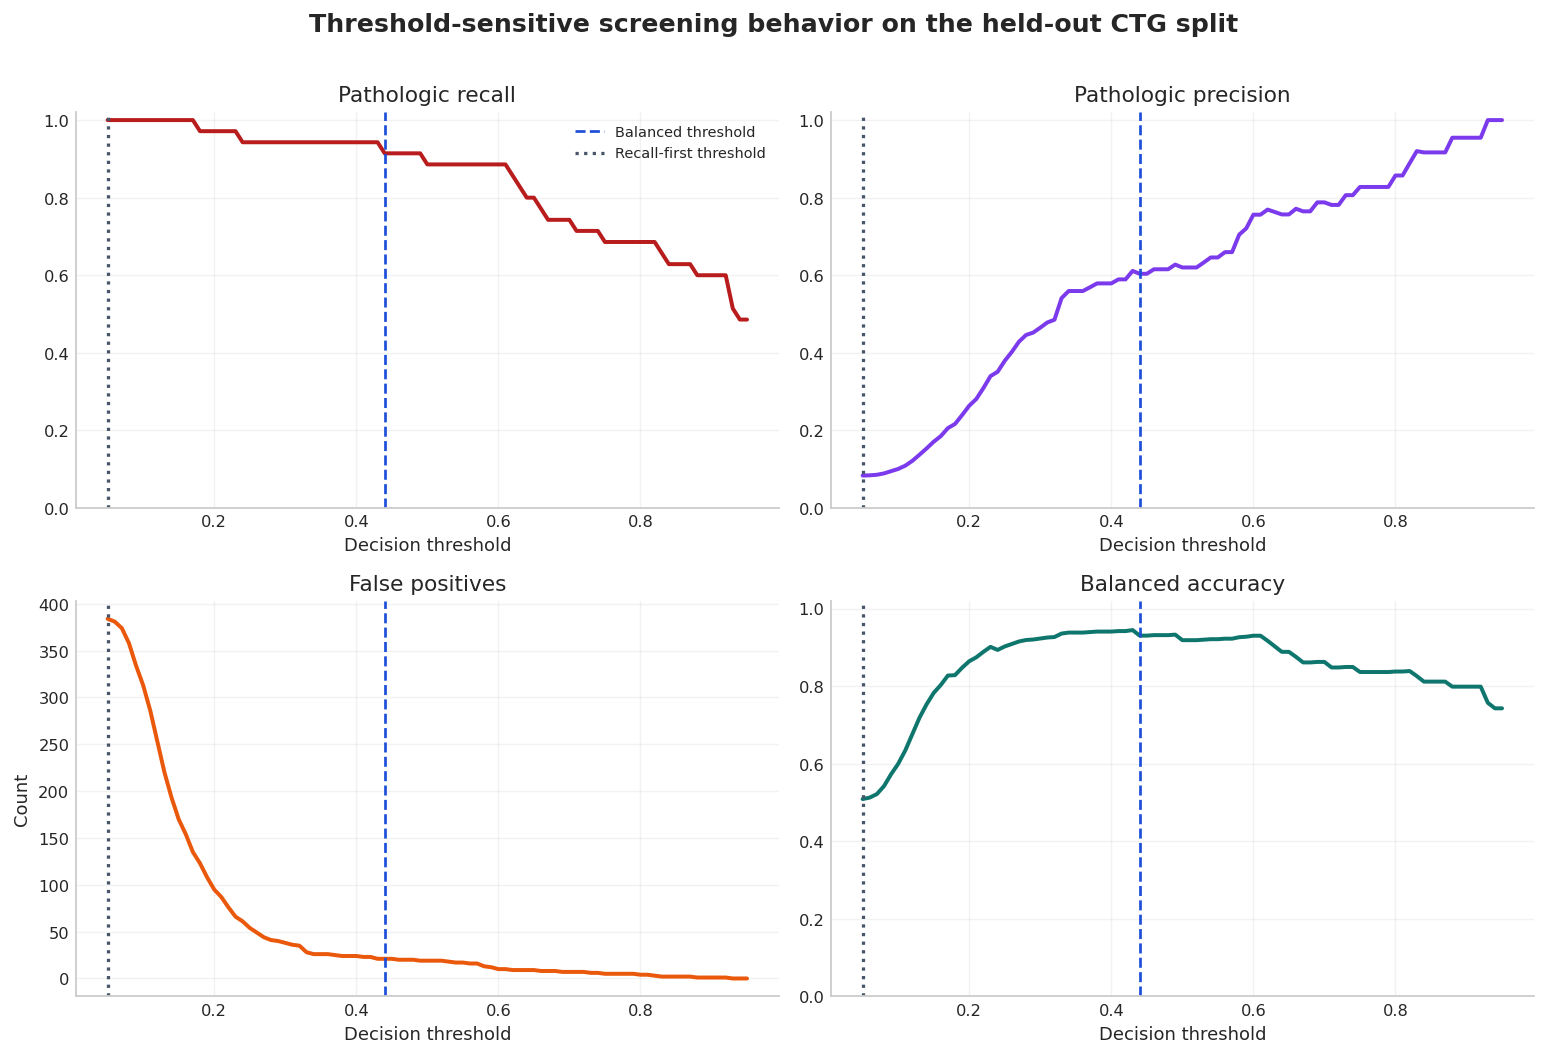

,mode,threshold,accuracy,balanced_acc,recall,specificity,precision,false_positives,false_negatives
0,balanced,0.44,0.9437,0.9303,0.9143,0.9463,0.6038,21,3
1,recall-first,0.05,0.0986,0.5090,1.0000,0.0179,0.0835,384,0


In [5]:
# ── Part III: operating-point analysis across decision thresholds ──────────────

test_threshold_rows = [
    summarize_operating_point(y[test_idx_np], final_probs[test_idx_np, 1], threshold)
    for threshold in np.arange(0.05, 0.96, 0.01)
]
test_threshold_df = pd.DataFrame(test_threshold_rows)
balanced_threshold = float(validation_operating_points["balanced"]["threshold"])
recall_first_threshold = float(validation_operating_points["recall-first"]["threshold"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    ("recall", "Pathologic recall", "#b91c1c"),
    ("precision", "Pathologic precision", "#7c3aed"),
    ("fp", "False positives", "#ea580c"),
    ("balanced_acc", "Balanced accuracy", "#0f766e"),
]

for ax, (column, title, color) in zip(axes.ravel(), plot_specs):
    ax.plot(test_threshold_df["threshold"], test_threshold_df[column], color=color, linewidth=2.2)
    ax.axvline(balanced_threshold, color="#1d4ed8", linestyle="--", linewidth=1.5, label="Balanced threshold")
    ax.axvline(recall_first_threshold, color="#475569", linestyle=":", linewidth=1.8, label="Recall-first threshold")
    ax.set_title(title)
    ax.set_xlabel("Decision threshold")
    ax.grid(alpha=0.25)
    if column != "fp":
        ax.set_ylim(0.0, 1.02)
    else:
        ax.set_ylabel("Count")

axes[0, 0].legend(fontsize=8, loc="best")
plt.suptitle("Threshold-sensitive screening behavior on the held-out CTG split", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_notebook_figure(fig, "bio_demo_operating_point_analysis.png")
plt.show()

comparison_df = pd.DataFrame(
    [
        {
            "mode": "balanced",
            "threshold": operating_points["balanced"]["threshold"],
            "accuracy": operating_points["balanced"]["accuracy"],
            "balanced_acc": operating_points["balanced"]["balanced_acc"],
            "recall": operating_points["balanced"]["recall"],
            "specificity": operating_points["balanced"]["specificity"],
            "precision": operating_points["balanced"]["precision"],
            "false_positives": operating_points["balanced"]["fp"],
            "false_negatives": operating_points["balanced"]["fn"],
        },
        {
            "mode": "recall-first",
            "threshold": operating_points["recall-first"]["threshold"],
            "accuracy": operating_points["recall-first"]["accuracy"],
            "balanced_acc": operating_points["recall-first"]["balanced_acc"],
            "recall": operating_points["recall-first"]["recall"],
            "specificity": operating_points["recall-first"]["specificity"],
            "precision": operating_points["recall-first"]["precision"],
            "false_positives": operating_points["recall-first"]["fp"],
            "false_negatives": operating_points["recall-first"]["fn"],
        },
    ]
)
display(comparison_df.round(4))

Saved figure assets -> ./notebooks/figures/bio_demo_aligned_biogcn_robustness.png
                     -> ./website/notebooks_html/figures/bio_demo_aligned_biogcn_robustness.png


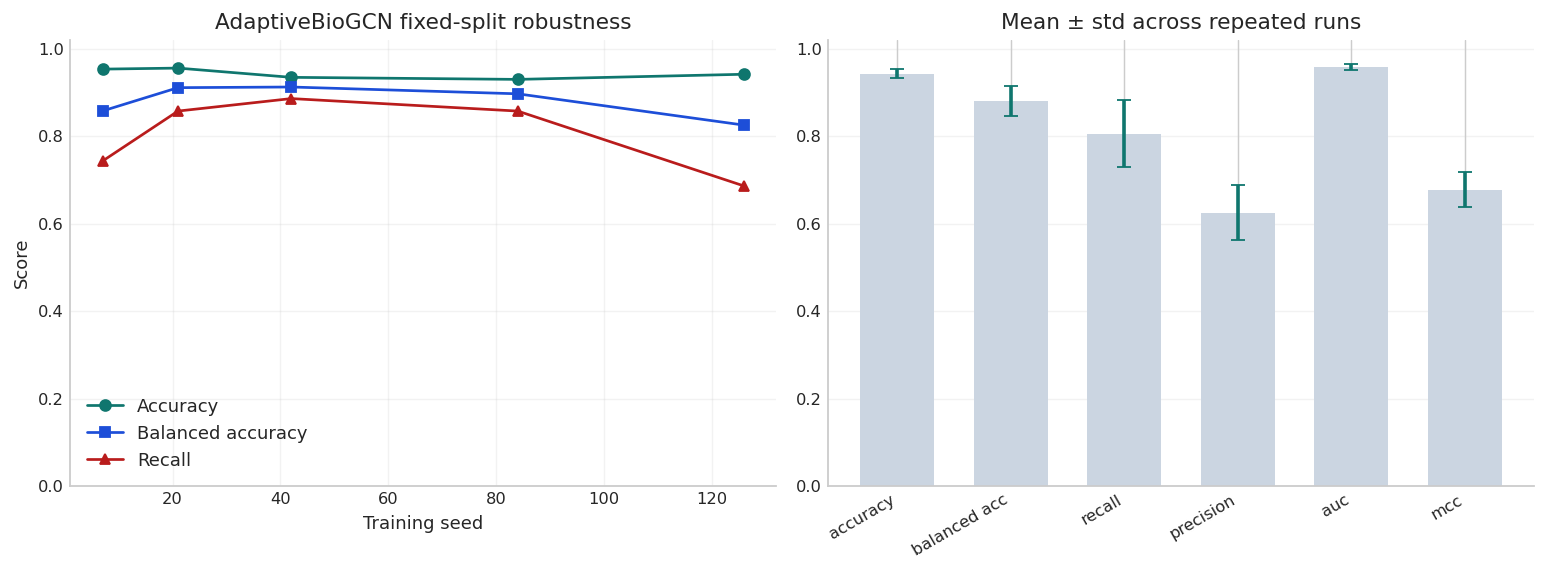

,seed,threshold,accuracy,balanced_acc,recall,precision,specificity,auc,auprc,mcc,false_negatives,false_positives,graph_density
0,7,0.72,0.9531,0.8574,0.7429,0.7027,0.9719,0.9461,0.7751,0.6969,9,11,0.0065
1,21,0.61,0.9554,0.9107,0.8571,0.6818,0.9642,0.9612,0.8476,0.7411,5,14,0.0065
2,42,0.36,0.9343,0.9122,0.8857,0.5636,0.9386,0.9624,0.8251,0.6751,4,24,0.0065
3,84,0.50,0.9296,0.8966,0.8571,0.5455,0.9361,0.9594,0.8249,0.6496,5,25,0.0065
4,126,0.67,0.9413,0.8250,0.6857,0.6316,0.9642,0.9627,0.8310,0.6261,11,14,0.0065


,metric,mean,std
0,accuracy,0.9427,0.0101
1,balanced_acc,0.8804,0.0340
2,recall,0.8057,0.0775
3,precision,0.6250,0.0623
4,auc,0.9584,0.0063
5,mcc,0.6778,0.0396


AdaptiveBioGCN robustness summary
  Accuracy          : 0.9427 ± 0.0101
  Balanced accuracy : 0.8804 ± 0.0340
  Recall            : 0.8057 ± 0.0775


In [6]:
# ── Part IV-A: AdaptiveBioGCN fixed-split robustness benchmark ─────────────────

ROBUST_SPLIT_SEED = 42
ROBUST_MODEL_SEEDS = [7, 21, 42, 84, 126]


def train_adaptive_biogcn_once(model_seed: int) -> dict:
    random.seed(model_seed)
    np.random.seed(model_seed)
    torch.manual_seed(model_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(model_seed)

    all_indices = np.arange(len(y))
    train_pool_idx, test_idx = train_test_split(
        all_indices,
        test_size=0.20,
        stratify=y,
        random_state=ROBUST_SPLIT_SEED,
    )
    train_idx, val_idx = train_test_split(
        train_pool_idx,
        test_size=0.15,
        stratify=y[train_pool_idx],
        random_state=ROBUST_SPLIT_SEED,
    )

    scaler_local = StandardScaler()
    scaler_local.fit(X_raw[train_idx])
    X_std_local = scaler_local.transform(X_raw).astype(np.float32)
    adjacency_local, normalized_local = build_normalized_knn_graph(X_std_local, k_neighbors=k_neighbors)

    Xt_local = torch.tensor(X_std_local, dtype=torch.float32, device=device)
    At_local = torch.tensor(normalized_local, dtype=torch.float32, device=device)
    yt_local = torch.tensor(y, dtype=torch.long, device=device)
    train_idx_local = torch.tensor(train_idx, dtype=torch.long, device=device)
    val_idx_local = torch.tensor(val_idx, dtype=torch.long, device=device)

    class_counts = np.bincount(y[train_idx], minlength=2).astype(np.float32)
    class_weights = class_counts.sum() / (len(class_counts) * np.maximum(class_counts, 1))
    class_weights[1] *= 1.10
    class_weights_t = torch.as_tensor(class_weights, dtype=torch.float32, device=device)

    model = AdaptiveBioGCN(in_features=X_std_local.shape[1], hidden_dim=48, dropout=0.15).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=5e-4)

    best_state = None
    best_metric = (-1.0, -1.0, float("-inf"))
    wait = 0
    for _epoch in range(1, 121):
        model.train()
        optimizer.zero_grad()
        logits = model(Xt_local, At_local)
        loss = F.cross_entropy(
            logits[train_idx_local],
            yt_local[train_idx_local],
            weight=class_weights_t,
        )
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(Xt_local, At_local)
            val_probs_local = F.softmax(val_logits[val_idx_local], dim=1).cpu().numpy()[:, 1]
            val_loss = F.cross_entropy(
                val_logits[val_idx_local],
                yt_local[val_idx_local],
                weight=class_weights_t,
            ).item()

        threshold_rows_local = [
            summarize_operating_point(y[val_idx], val_probs_local, threshold)
            for threshold in np.arange(0.20, 0.81, 0.01)
        ]
        threshold_df_local = pd.DataFrame(threshold_rows_local)
        best_row_local = threshold_df_local.sort_values(
            ["balanced_acc", "accuracy", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, True],
        ).iloc[0]

        checkpoint_metric = (
            float(best_row_local["balanced_acc"]),
            float(best_row_local["accuracy"]),
            -float(val_loss),
        )
        if checkpoint_metric > best_metric:
            best_metric = checkpoint_metric
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= 20:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_probs_local = F.softmax(model(Xt_local, At_local), dim=1).cpu().numpy()

    threshold_rows_local = [
        summarize_operating_point(y[val_idx], final_probs_local[val_idx, 1], threshold)
        for threshold in np.arange(0.20, 0.81, 0.01)
    ]
    threshold_df_local = pd.DataFrame(threshold_rows_local)
    selected_row_local = threshold_df_local.sort_values(
        ["balanced_acc", "accuracy", "recall", "precision", "threshold"],
        ascending=[False, False, False, False, True],
    ).iloc[0]
    selected_eval_local = summarize_operating_point(y[test_idx], final_probs_local[test_idx, 1], selected_row_local["threshold"])

    return {
        "seed": model_seed,
        "threshold": float(selected_eval_local["threshold"]),
        "accuracy": float(selected_eval_local["accuracy"]),
        "balanced_acc": float(selected_eval_local["balanced_acc"]),
        "recall": float(selected_eval_local["recall"]),
        "precision": float(selected_eval_local["precision"]),
        "specificity": float(selected_eval_local["specificity"]),
        "auc": float(selected_eval_local["auc"]),
        "auprc": float(selected_eval_local["auprc"]),
        "mcc": float(selected_eval_local["mcc"]),
        "false_negatives": int(selected_eval_local["fn"]),
        "false_positives": int(selected_eval_local["fp"]),
        "graph_density": float(adjacency_local.sum() / 2 / max(adjacency_local.shape[0] * (adjacency_local.shape[0] - 1) / 2, 1)),
    }


robustness_df = pd.DataFrame([train_adaptive_biogcn_once(seed) for seed in ROBUST_MODEL_SEEDS])
robustness_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "mean": float(robustness_df[metric].mean()),
            "std": float(robustness_df[metric].std(ddof=0)),
        }
        for metric in ["accuracy", "balanced_acc", "recall", "precision", "auc", "mcc"]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(robustness_df["seed"], robustness_df["accuracy"], marker="o", color="#0f766e", label="Accuracy")
axes[0].plot(robustness_df["seed"], robustness_df["balanced_acc"], marker="s", color="#1d4ed8", label="Balanced accuracy")
axes[0].plot(robustness_df["seed"], robustness_df["recall"], marker="^", color="#b91c1c", label="Recall")
axes[0].set_xlabel("Training seed")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.0, 1.02)
axes[0].set_title("AdaptiveBioGCN fixed-split robustness")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

x_positions = np.arange(len(robustness_summary))
axes[1].bar(x_positions, robustness_summary["mean"], color="#cbd5e1", width=0.65)
axes[1].errorbar(
    x_positions,
    robustness_summary["mean"],
    yerr=robustness_summary["std"],
    fmt="none",
    ecolor="#0f766e",
    elinewidth=2,
    capsize=4,
)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels([metric.replace("_", " ") for metric in robustness_summary["metric"]], rotation=30, ha="right")
axes[1].set_ylim(0.0, 1.02)
axes[1].set_title("Mean ± std across repeated runs")
axes[1].grid(alpha=0.25, axis="y")

plt.tight_layout()
save_notebook_figure(fig, "bio_demo_aligned_biogcn_robustness.png")
plt.show()

display(robustness_df.round(4))
display(robustness_summary.round(4))
print("AdaptiveBioGCN robustness summary")
print(f"  Accuracy          : {robustness_df['accuracy'].mean():.4f} ± {robustness_df['accuracy'].std(ddof=0):.4f}")
print(f"  Balanced accuracy : {robustness_df['balanced_acc'].mean():.4f} ± {robustness_df['balanced_acc'].std(ddof=0):.4f}")
print(f"  Recall            : {robustness_df['recall'].mean():.4f} ± {robustness_df['recall'].std(ddof=0):.4f}")

Saved figure assets -> ./notebooks/figures/bio_demo_graph_homophily.png
                     -> ./website/notebooks_html/figures/bio_demo_graph_homophily.png


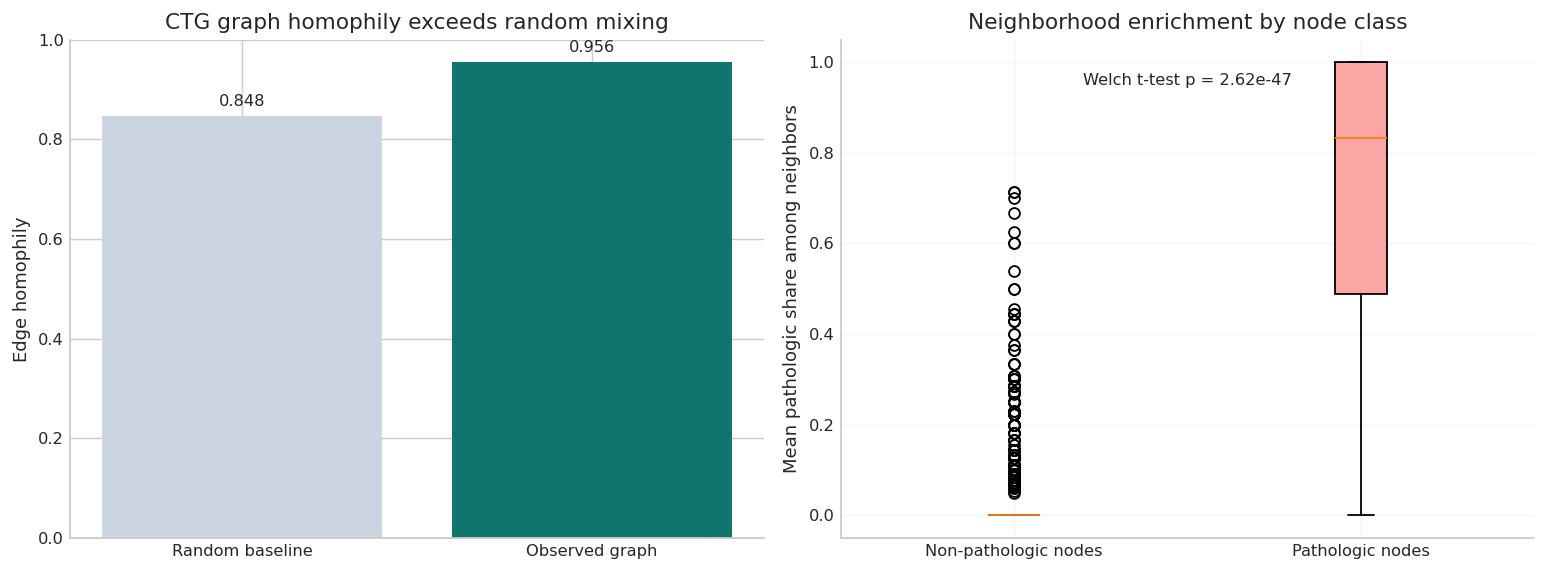

Graph homophily summary
  Observed edge homophily : 0.9561
  Random baseline         : 0.8477
  Homophily excess        : 0.1084
  Welch t-test p-value    : 2.6168e-47


In [7]:
# ── Part IV-B: graph-homophily validation ──────────────────────────────────────

train_adj = A_graph[np.ix_(train_idx_np, train_idx_np)].copy()
train_labels_binary = y[train_idx_np]
edge_rows, edge_cols = np.where(np.triu(train_adj, k=1) > 0)
edge_same_label = (train_labels_binary[edge_rows] == train_labels_binary[edge_cols]).astype(np.float32)
observed_homophily = float(edge_same_label.mean())
pathologic_prevalence = float(train_labels_binary.mean())
random_baseline_homophily = pathologic_prevalence ** 2 + (1.0 - pathologic_prevalence) ** 2

neighbor_fraction = []
for node_idx in range(train_adj.shape[0]):
    neighbors = np.where(train_adj[node_idx] > 0)[0]
    neighbors = neighbors[neighbors != node_idx]
    if len(neighbors) == 0:
        neighbor_fraction.append(0.0)
    else:
        neighbor_fraction.append(float(train_labels_binary[neighbors].mean()))
neighbor_fraction = np.asarray(neighbor_fraction)
positive_neighbor_fraction = neighbor_fraction[train_labels_binary == 1]
negative_neighbor_fraction = neighbor_fraction[train_labels_binary == 0]

t_statistic, p_value = stats.ttest_ind(
    positive_neighbor_fraction,
    negative_neighbor_fraction,
    equal_var=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(
    ["Random baseline", "Observed graph"],
    [random_baseline_homophily, observed_homophily],
    color=["#cbd5e1", "#0f766e"],
)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("Edge homophily")
axes[0].set_title("CTG graph homophily exceeds random mixing")
for idx, value in enumerate([random_baseline_homophily, observed_homophily]):
    axes[0].text(idx, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)

box_data = [negative_neighbor_fraction, positive_neighbor_fraction]
box = axes[1].boxplot(box_data, patch_artist=True, labels=["Non-pathologic nodes", "Pathologic nodes"])
for patch, color in zip(box["boxes"], ["#93c5fd", "#fca5a5"]):
    patch.set_facecolor(color)
axes[1].set_ylabel("Mean pathologic share among neighbors")
axes[1].set_title("Neighborhood enrichment by node class")
axes[1].grid(alpha=0.2)
axes[1].text(
    1.5,
    max(float(neighbor_fraction.max()), 0.2) * 0.95,
    f"Welch t-test p = {p_value:.2e}",
    ha="center",
    fontsize=9,
)

plt.tight_layout()
save_notebook_figure(fig, "bio_demo_graph_homophily.png")
plt.show()

print("Graph homophily summary")
print(f"  Observed edge homophily : {observed_homophily:.4f}")
print(f"  Random baseline         : {random_baseline_homophily:.4f}")
print(f"  Homophily excess        : {observed_homophily - random_baseline_homophily:.4f}")
print(f"  Welch t-test p-value    : {p_value:.4e}")

Saved figure assets -> ./notebooks/figures/bio_demo_calibration_uncertainty.png
                     -> ./website/notebooks_html/figures/bio_demo_calibration_uncertainty.png


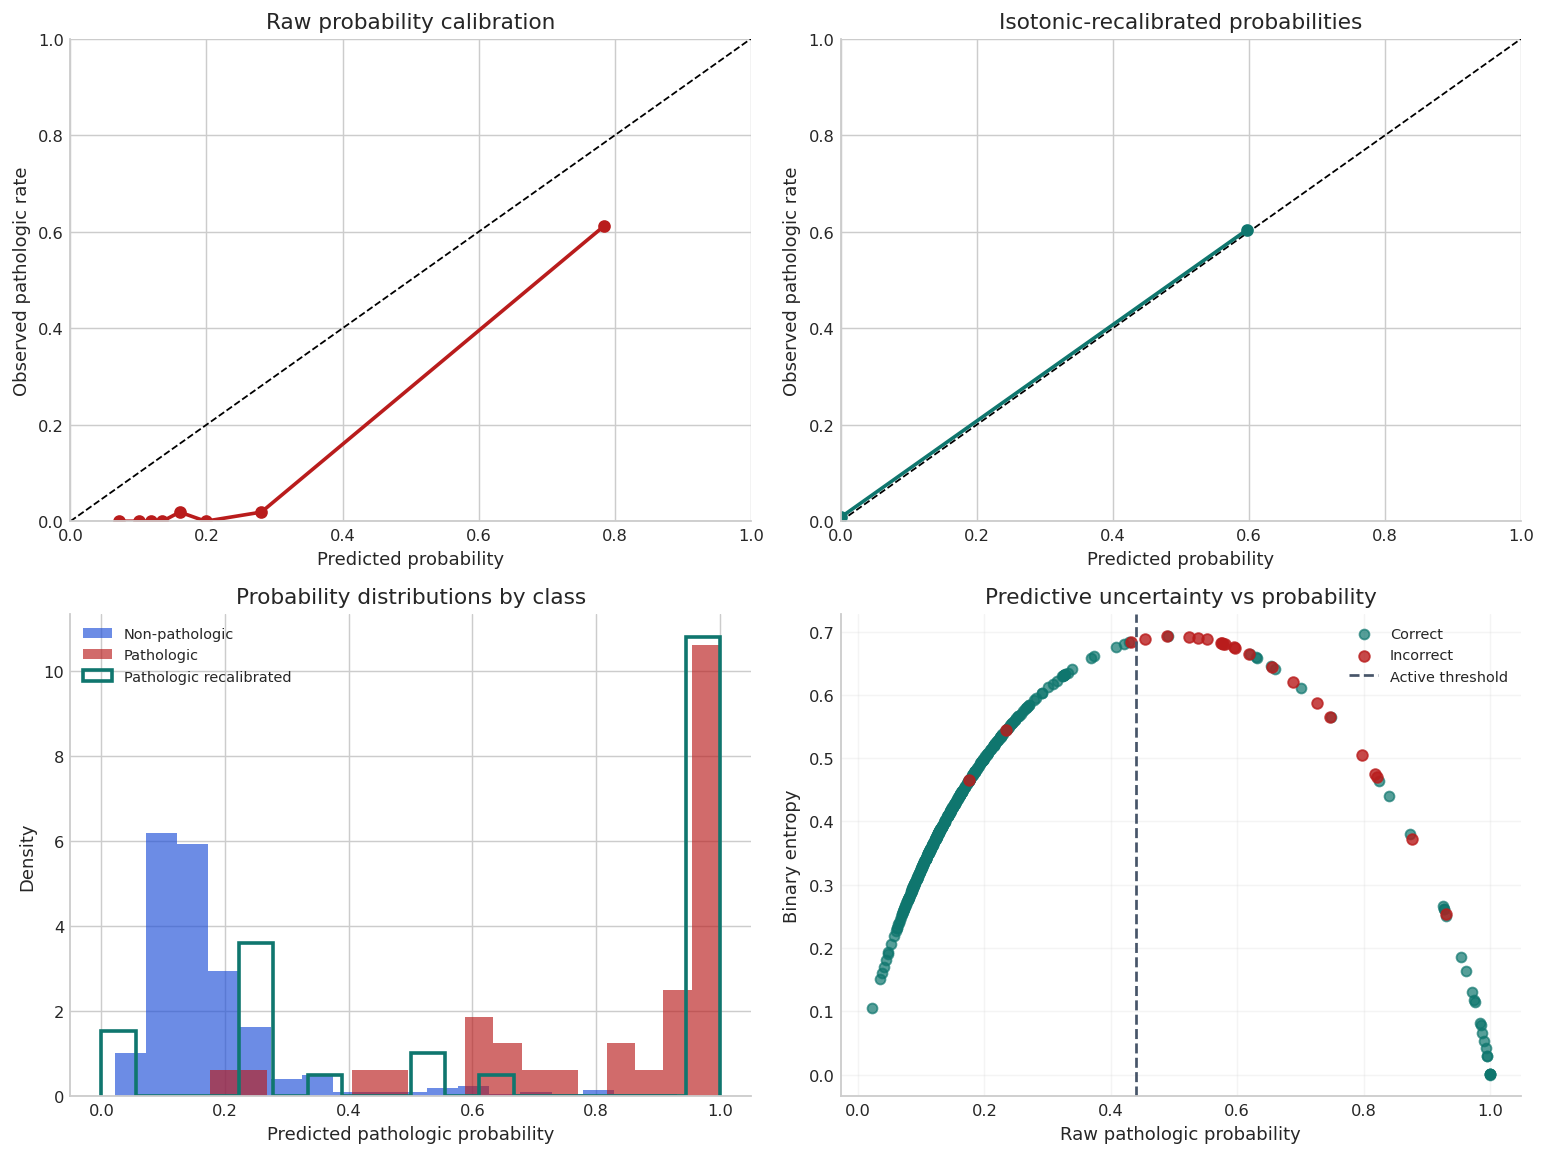

Calibration summary
  Raw mean probability (test)        : 0.2322
  Recalibrated mean probability      : 0.0743
  Mean uncertainty, correct cases    : 0.3976
  Mean uncertainty, incorrect cases  : 0.5990


In [8]:
# ── Part IV-C: calibration and uncertainty audit ───────────────────────────────

val_probs = final_probs[val_idx_np, 1]
test_probs = final_probs[test_idx_np, 1]
y_val = y[val_idx_np]
y_test = y[test_idx_np]

iso_calibrator = IsotonicRegression(out_of_bounds="clip")
iso_calibrator.fit(val_probs, y_val)
calibrated_test_probs = iso_calibrator.transform(test_probs)

raw_curve_true, raw_curve_pred = calibration_curve(y_test, test_probs, n_bins=8, strategy="quantile")
cal_curve_true, cal_curve_pred = calibration_curve(y_test, calibrated_test_probs, n_bins=8, strategy="quantile")

entropy = -(test_probs * np.log(np.clip(test_probs, 1e-6, 1.0)) + (1.0 - test_probs) * np.log(np.clip(1.0 - test_probs, 1e-6, 1.0)))
correct_mask = y_te_pred == y_test

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0, 0].plot(raw_curve_pred, raw_curve_true, marker="o", color="#b91c1c", linewidth=2)
axes[0, 0].set_title("Raw probability calibration")
axes[0, 0].set_xlabel("Predicted probability")
axes[0, 0].set_ylabel("Observed pathologic rate")
axes[0, 0].set_xlim(0.0, 1.0)
axes[0, 0].set_ylim(0.0, 1.0)

axes[0, 1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0, 1].plot(cal_curve_pred, cal_curve_true, marker="o", color="#0f766e", linewidth=2)
axes[0, 1].set_title("Isotonic-recalibrated probabilities")
axes[0, 1].set_xlabel("Predicted probability")
axes[0, 1].set_ylabel("Observed pathologic rate")
axes[0, 1].set_xlim(0.0, 1.0)
axes[0, 1].set_ylim(0.0, 1.0)

axes[1, 0].hist(test_probs[y_test == 0], bins=18, alpha=0.65, color="#1d4ed8", label="Non-pathologic", density=True)
axes[1, 0].hist(test_probs[y_test == 1], bins=18, alpha=0.65, color="#b91c1c", label="Pathologic", density=True)
axes[1, 0].hist(calibrated_test_probs[y_test == 1], bins=18, histtype="step", linewidth=2, color="#0f766e", label="Pathologic recalibrated", density=True)
axes[1, 0].set_title("Probability distributions by class")
axes[1, 0].set_xlabel("Predicted pathologic probability")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend(fontsize=8)

axes[1, 1].scatter(test_probs[correct_mask], entropy[correct_mask], color="#0f766e", alpha=0.7, s=30, label="Correct")
axes[1, 1].scatter(test_probs[~correct_mask], entropy[~correct_mask], color="#b91c1c", alpha=0.8, s=35, label="Incorrect")
axes[1, 1].axvline(decision_threshold, color="#475569", linestyle="--", linewidth=1.5, label="Active threshold")
axes[1, 1].set_title("Predictive uncertainty vs probability")
axes[1, 1].set_xlabel("Raw pathologic probability")
axes[1, 1].set_ylabel("Binary entropy")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
save_notebook_figure(fig, "bio_demo_calibration_uncertainty.png")
plt.show()

print("Calibration summary")
print(f"  Raw mean probability (test)        : {test_probs.mean():.4f}")
print(f"  Recalibrated mean probability      : {calibrated_test_probs.mean():.4f}")
print(f"  Mean uncertainty, correct cases    : {entropy[correct_mask].mean():.4f}")
print(f"  Mean uncertainty, incorrect cases  : {entropy[~correct_mask].mean():.4f}")

Saved figure assets -> ./notebooks/figures/bio_demo_feature_saliency.png
                     -> ./website/notebooks_html/figures/bio_demo_feature_saliency.png


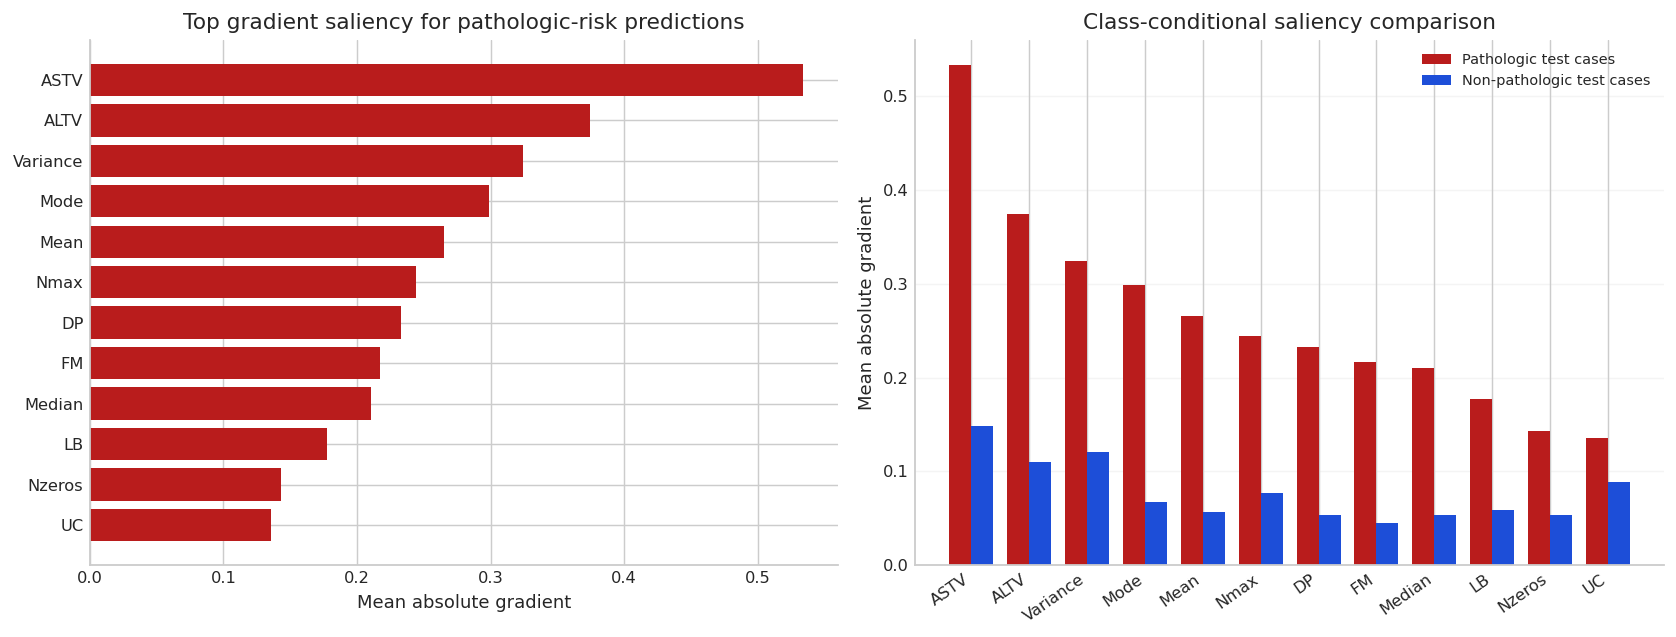

,feature,pathologic_mean_abs_grad,non_pathologic_mean_abs_grad
0,ASTV,0.533589,0.148560
1,ALTV,0.374522,0.109737
2,Variance,0.324622,0.120154
3,Mode,0.298624,0.066806
4,Mean,0.265135,0.056189
5,Nmax,0.243969,0.076587
6,DP,0.232938,0.053092
7,FM,0.217115,0.045071
8,Median,0.210346,0.053398
9,LB,0.177216,0.059091


In [9]:
# ── Part IV-D: gradient saliency analysis ───────────────────────────────────────

bio_model.eval()
Xt_saliency = Xt.clone().detach().requires_grad_(True)
logits_saliency = bio_model(Xt_saliency, At)
pathologic_logit = logits_saliency[test_idx_t, 1].sum()
pathologic_logit.backward()

gradients = Xt_saliency.grad[test_idx_t].detach().cpu().numpy()
abs_gradients = np.abs(gradients)
pathologic_test_mask = y[test_idx_np] == 1
if pathologic_test_mask.any():
    pathologic_saliency = abs_gradients[pathologic_test_mask].mean(axis=0)
else:
    pathologic_saliency = abs_gradients.mean(axis=0)
nonpath_saliency = abs_gradients[~pathologic_test_mask].mean(axis=0)

top_idx = np.argsort(pathologic_saliency)[-12:][::-1]
saliency_df = pd.DataFrame(
    {
        "feature": feature_names[top_idx],
        "pathologic_mean_abs_grad": pathologic_saliency[top_idx],
        "non_pathologic_mean_abs_grad": nonpath_saliency[top_idx],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_df = saliency_df.iloc[::-1]
axes[0].barh(plot_df["feature"], plot_df["pathologic_mean_abs_grad"], color="#b91c1c")
axes[0].set_title("Top gradient saliency for pathologic-risk predictions")
axes[0].set_xlabel("Mean absolute gradient")

x = np.arange(len(saliency_df))
width = 0.38
axes[1].bar(x - width / 2, saliency_df["pathologic_mean_abs_grad"], width=width, color="#b91c1c", label="Pathologic test cases")
axes[1].bar(x + width / 2, saliency_df["non_pathologic_mean_abs_grad"], width=width, color="#1d4ed8", label="Non-pathologic test cases")
axes[1].set_xticks(x)
axes[1].set_xticklabels(saliency_df["feature"], rotation=35, ha="right")
axes[1].set_ylabel("Mean absolute gradient")
axes[1].set_title("Class-conditional saliency comparison")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2, axis="y")

plt.tight_layout()
save_notebook_figure(fig, "bio_demo_feature_saliency.png")
plt.show()

display(saliency_df.round(6))

In [11]:
# ── Part IV-E: export notebook HTML and artifact manifest ──────────────────────

expected_bio_figures = [
    "bio_demo_pca_audit.png",
    "bio_demo_heldout_evaluation.png",
    "bio_demo_operating_point_analysis.png",
    "bio_demo_aligned_biogcn_robustness.png",
    "bio_demo_graph_homophily.png",
    "bio_demo_calibration_uncertainty.png",
    "bio_demo_feature_saliency.png",
]

manifest = pd.DataFrame(
    {
        "figure": expected_bio_figures,
        "notebook_path": [str(notebook_figure_dir / name) for name in expected_bio_figures],
        "website_path": [str(html_figure_dir / name) for name in expected_bio_figures],
        "exists_in_notebook_dir": [(notebook_figure_dir / name).exists() for name in expected_bio_figures],
        "exists_in_website_dir": [(html_figure_dir / name).exists() for name in expected_bio_figures],
    }
)

display(manifest)
html_path = export_notebook_html("bio_demo.html")
print(f"Exported HTML to {html_path}")

,figure,notebook_path,website_path,exists_in_notebook_dir,exists_in_website_dir
0,bio_demo_pca_audit.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True
1,bio_demo_heldout_evaluation.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True
2,bio_demo_operating_point_analysis.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True
3,bio_demo_aligned_biogcn_robustness.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True
4,bio_demo_graph_homophily.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True
5,bio_demo_calibration_uncertainty.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True
6,bio_demo_feature_saliency.png,~/Library/CloudStorage/OneDrive-SA...,~/Library/CloudStorage/OneDrive-SA...,True,True


Exported HTML: ./website/notebooks_html/bio_demo.html
Exported HTML to ./website/notebooks_html/bio_demo.html
